In [181]:
# Load libraries and data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set style for better-looking plots
plt.rcParams['figure.figsize'] = (12, 8)

# Load the merged data
data = pd.read_csv('../data/processed/llm_as_judge_results.csv')
raw_data = pd.read_csv('../data/raw/item_level_data.csv') # ground truth
valid_pids = pd.read_csv('../data/raw/attention_check_failed.csv')

# Merge on BOTH participant_id and headline to avoid row multiplication
data = data.merge(
    raw_data[['participant_id', 'headline', 'ground_truth_with_AI', "before_AI_Real_Fake", "with_AI_Real_Fake", "after_AI_Real_Fake", "after_AI_ground_truth"]], 
    on=['participant_id', 'headline'], 
    how='left'
).rename(columns={'ground_truth_with_AI': 'ground_truth', 'before_AI_Real_Fake': 'initial_rating', 'with_AI_Real_Fake': 'final_rating', 'after_AI_Real_Fake': 'unassisted_rating', 'after_AI_ground_truth': 'unassisted_ground_truth'})

data['ground_truth'] = data['ground_truth'].str.capitalize() #first letter uppercase
data['initial_rating'] = data['initial_rating'].str.capitalize() #first letter uppercase
data['congruent_belief'] = data.apply(lambda row: 'Congruent' if (row['ground_truth'] == row['initial_rating']) else 'Incongruent', axis=1)
data['accuracy_with'] = data["final_rating"].str.capitalize() == data["ground_truth"].str.capitalize()
data['accuracy_unassisted'] = data["unassisted_rating"].str.capitalize() == data["unassisted_ground_truth"].str.capitalize()

# Only include participants also in processed data
condition1_only = raw_data[raw_data.condition == "Persuasive"]['participant_id'].unique()
data = data[data['participant_id'].isin(valid_pids['participant_id']) & data['participant_id'].isin(condition1_only)]


# Show
data.to_csv('../data/processed/llm_as_judge_results_filtered_pids.csv', index=False)
data.head(3)

,participant_id,headline,gave_away_ground_truth,asked_broad_questions,asked_guiding_questions,probed_deeper_over_multiple_messages,changed_focus_every_question,ask_for_source_checking,cross_verification_prompting,image_forensics_questions,...,reflect_on_process,Week,ground_truth,initial_rating,final_rating,unassisted_rating,unassisted_ground_truth,congruent_belief,accuracy_with,accuracy_unassisted
40,5e35373e1ddb124e6c306747,"Senator Christopher J. Dodd, with his wife and...",0,0,0,1,0,0,1,1,...,0,Week0,Fake,Real,FAKE,Fake,fake,Incongruent,True,True
41,5e35373e1ddb124e6c306747,An immigrant viciously attacks medical personn...,2,1,1,1,0,0,1,0,...,0,Week0,Fake,Fake,FAKE,Fake,fake,Congruent,True,True
42,5e35373e1ddb124e6c306747,Pictures of King Abdullah II of Jordan at a fr...,2,0,1,1,0,0,0,0,...,0,Week0,Real,Fake,REAL,Real,real,Incongruent,True,True


In [136]:
data.gave_away_ground_truth.value_counts()

gave_away_ground_truth
2    73
1    13
0    10
Name: count, dtype: int64

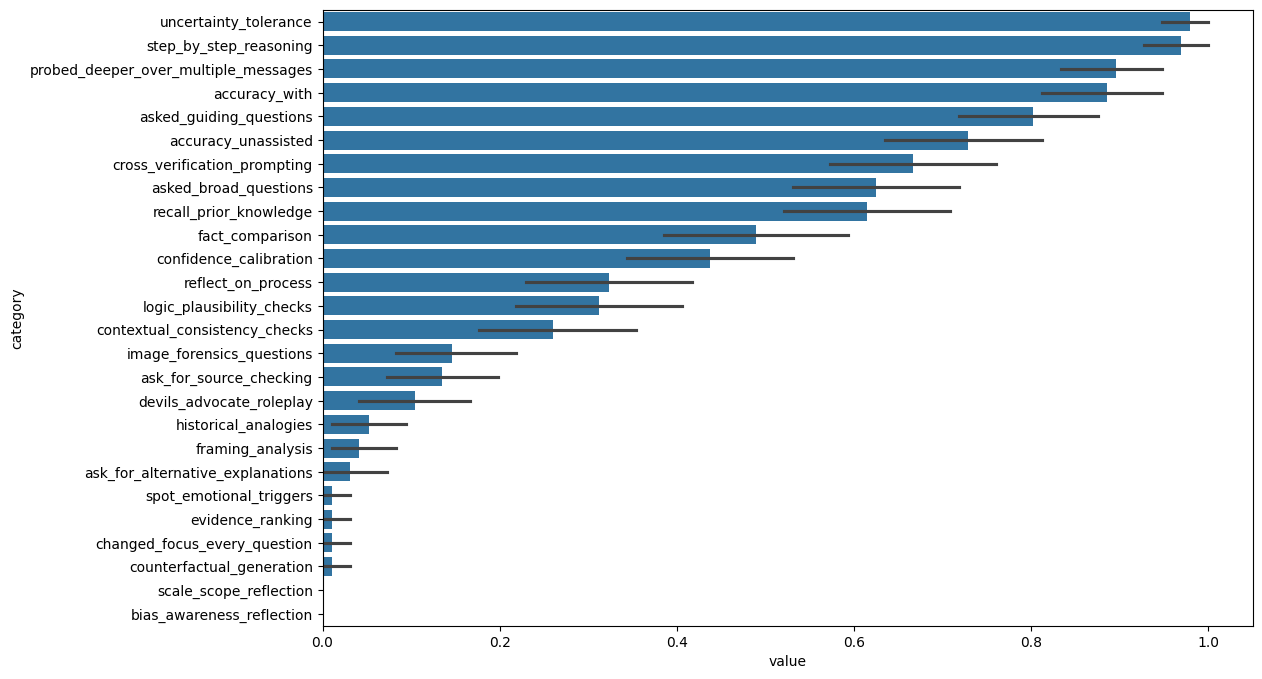

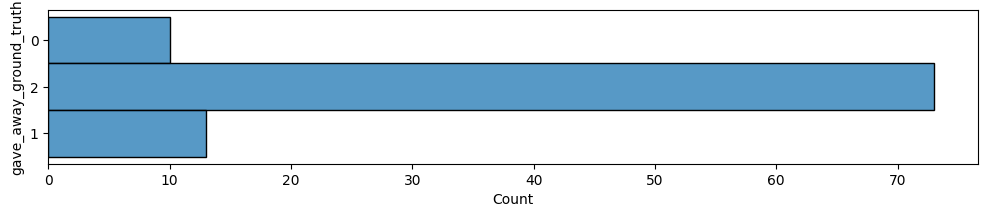

In [137]:
# plot vertical bar chart of frequency of each category in all columns except 'participant_id' and 'headline' and 'Week'
category_columns = data.columns.difference(['participant_id', 'headline', 'Week', 'gave_away_ground_truth'])

# Melt the dataframe to include all category columns on the y-axis with frequency on the x-axis
plot_data = data.melt(value_vars=category_columns, var_name='category', value_name='value')
plot_data['value'] = pd.to_numeric(plot_data['value'], errors='coerce')
plot_data = plot_data.dropna(subset=['value'])

# Order categories by mean value
category_order = plot_data.groupby('category')['value'].mean().sort_values(ascending=False).index
plot_data['category'] = pd.Categorical(plot_data['category'], categories=category_order, ordered=True)

# Plot vertical frequency plot with seaborn
fig = plt.figure(figsize=(12, 8))
fig = sns.barplot(data=plot_data, y='category', x='value')
plt.show()

# Plot when gave away truth
fig = plt.figure(figsize=(12, 2))
fig = sns.histplot(data=data, y='gave_away_ground_truth')
# plt.yticks(ticks=[0, 1, 2], labels=['Beginning', 'End', 'Never'])
plt.show()


In [93]:
temp = data[data.gave_away_ground_truth!="ERROR"]
# change column values name with [0='Beginning', 1='End', 2='Never'] for temp
temp['gave_away_ground_truth'] = temp.apply(lambda x: 'Beginning' if x['gave_away_ground_truth']=="0" else ('End' if x['gave_away_ground_truth']=="1" else 'Never'), axis=1)
temp['gave_away_ground_truth'].value_counts()

/var/folders/p4/hpn1jhfx39bdjtyx1rrh_lrw0000gn/T/ipykernel_3693/2761569707.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['gave_away_ground_truth'] = temp.apply(lambda x: 'Beginning' if x['gave_away_ground_truth']=="0" else ('End' if x['gave_away_ground_truth']=="1" else 'Never'), axis=1)


gave_away_ground_truth
Never        41075
End           8762
Beginning     6172
Name: count, dtype: int64

{'asked_broad_questions': {'description': 'Did the AI assistant ask broad questions during the conversation?', 'example': 'What do you think about this headline? How does this make you feel?', '0': 'not_asked', '1': 'asked'}, 'asked_guiding_questions': {'description': 'Did the AI assistant ask guiding questions during the conversation?', 'example': "Let's think about the source of this information. What details can you verify?", '0': 'not_asked', '1': 'asked'}, 'probed_deeper_over_multiple_messages': {'description': 'Did the AI assistant probe deeper over multiple messages during the conversation?', 'example': 'Following up on your previous answer, can you tell me more about... What else might explain this?', '0': 'not_probed', '1': 'probed_deeper'}, 'changed_focus_every_question': {'description': 'Did the AI assistant change focus with every question during the conversation?', 'example': 'The assistant first asked about source, then emotions, then image details without building on pre

KeyError: "None of [Index(['ask_for_source_checking', 'cross_verification_prompting',\n       'image_forensics_questions', 'contextual_consistency_checks'],\n      dtype='object')] are in the [columns]"

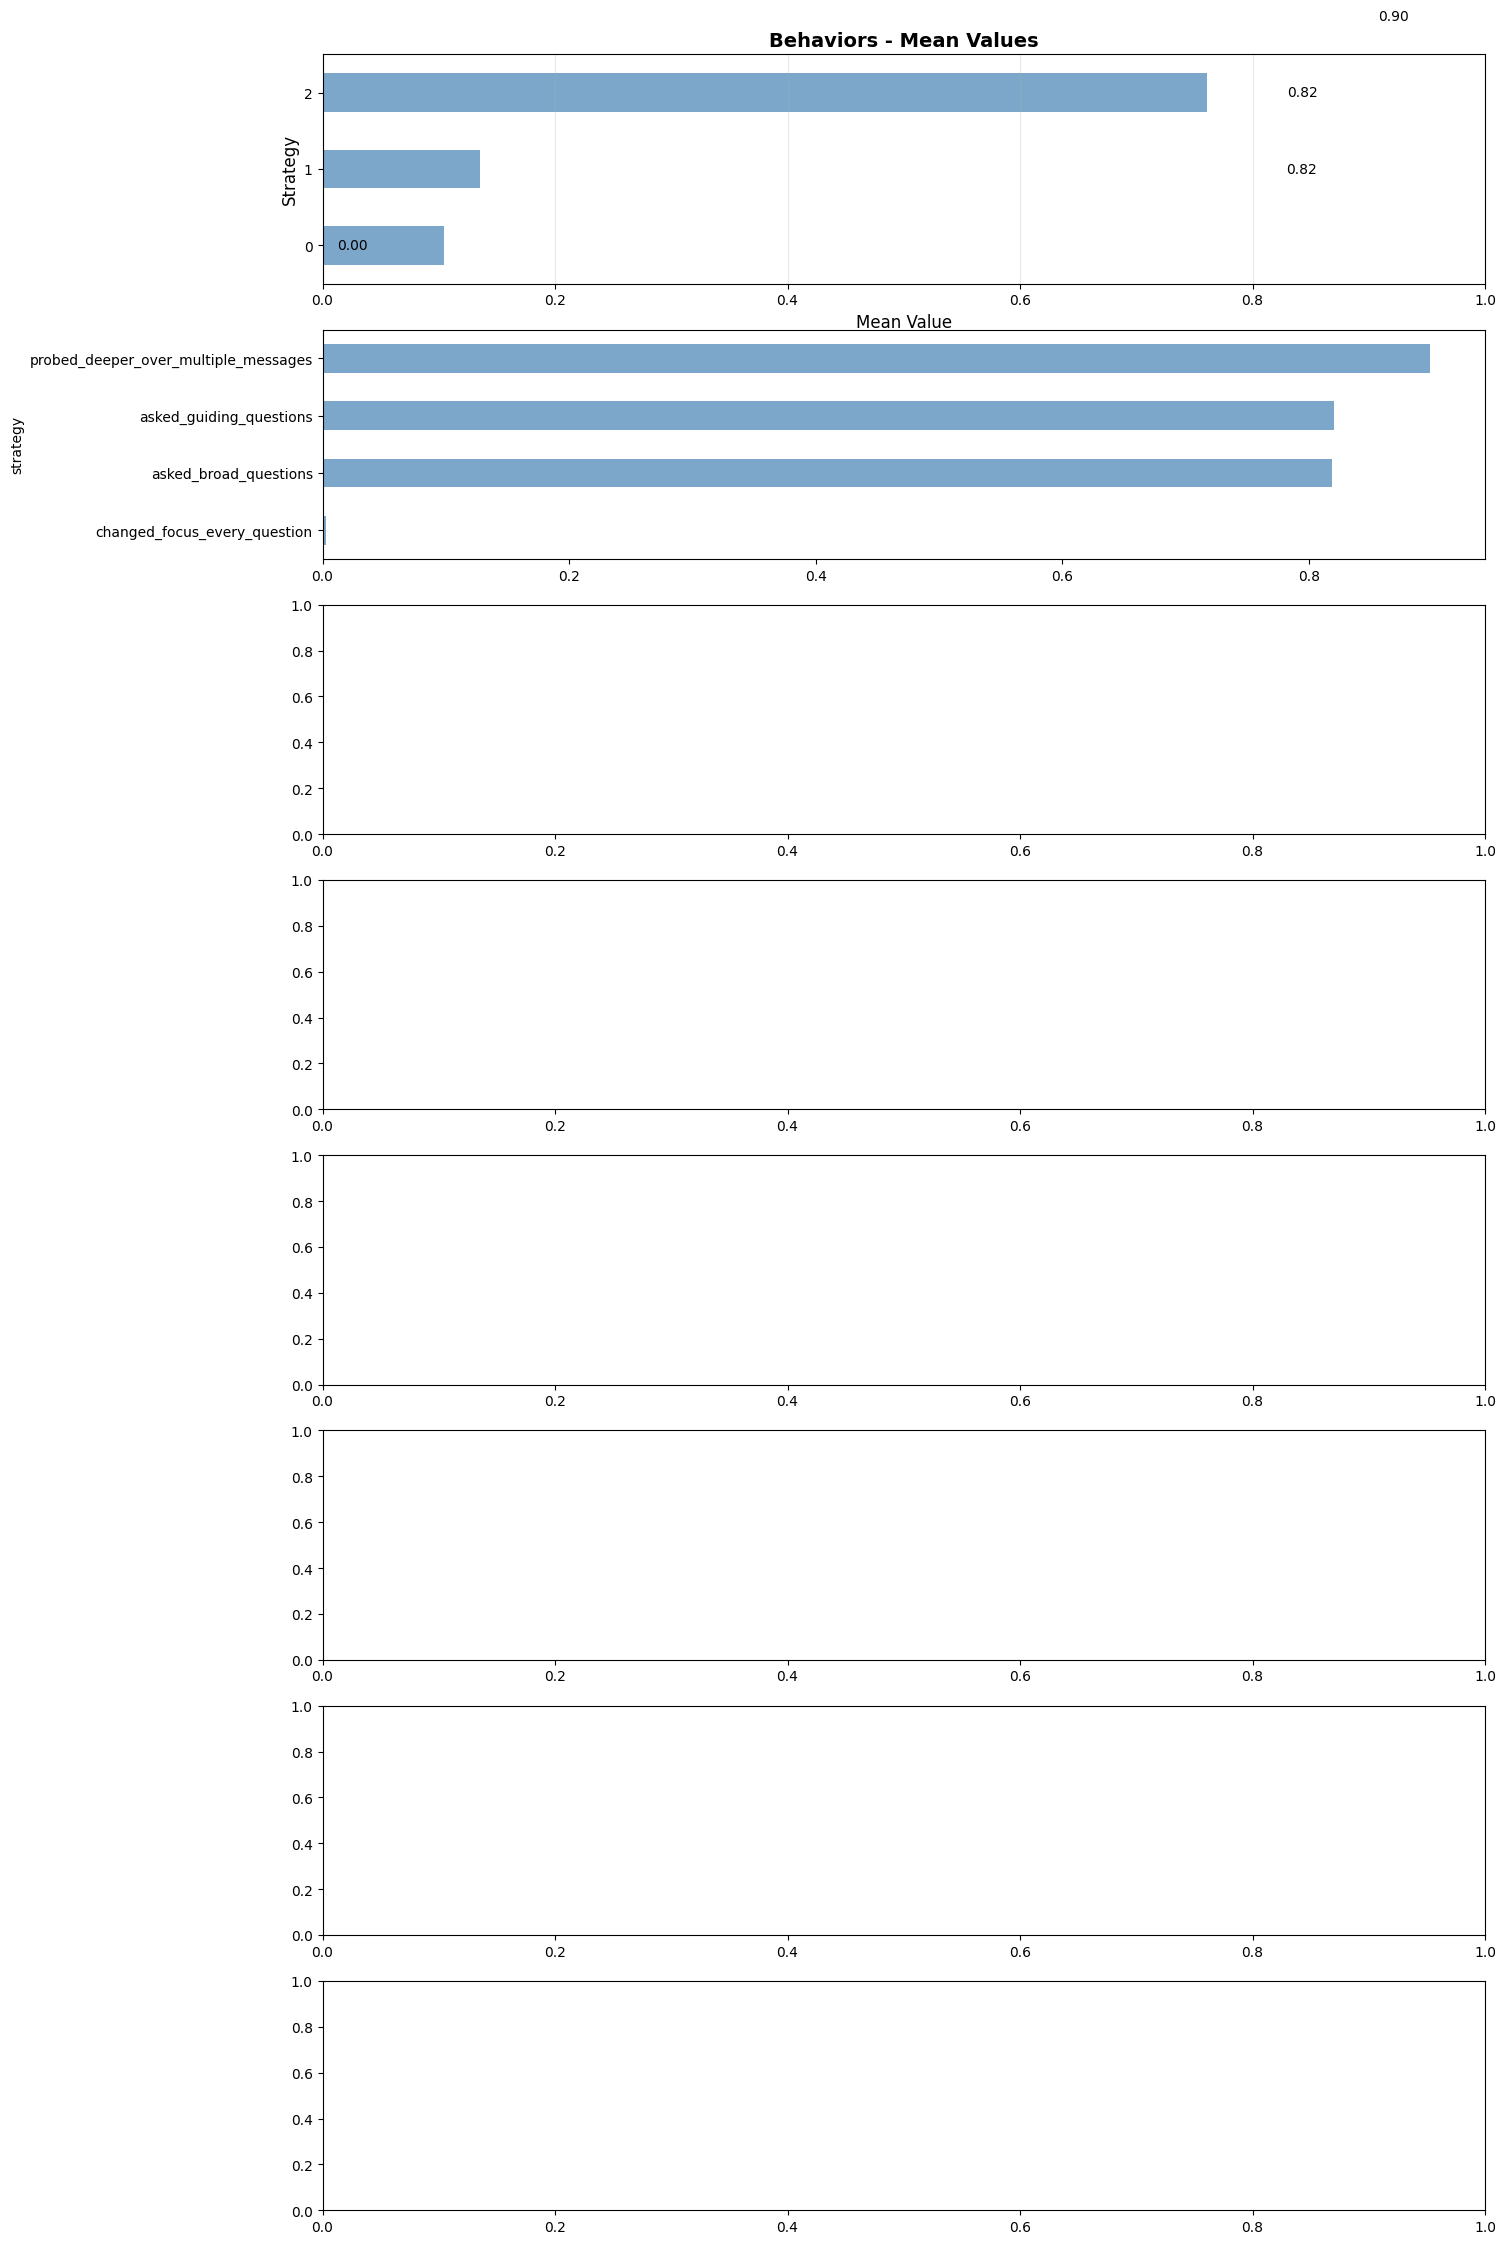

In [116]:
# Import classifier categories from classifier_prompts.py
import sys
sys.path.append('classifiers_llm')
from classifier_prompts import behaviors, evidence_strategies, reasoning_strategies, emotional_strategies, knowledge_activation, questioning_types, metacognitive

# Create a mapping of all classifier categories
print({k: v for k, v in behaviors.items() if k != "gave_away_ground_truth"},)
print(behaviors)
all_categories = {
    'Behaviors': {k: v for k, v in behaviors.items() if k != "gave_away_ground_truth"},
    'Evidence Strategies': evidence_strategies,
    'Reasoning Strategies': reasoning_strategies,
    'Emotional Strategies': emotional_strategies,
    'Knowledge Activation': knowledge_activation,
    'Questioning Types': questioning_types,
    'Metacognitive': metacognitive
}

# Create subplots for each category group
fig, axes = plt.subplots(len(all_categories)+1, 1, figsize=(15, 4 * len(all_categories)))
if len(all_categories) == 1:
    axes = [axes]

# In the first row we will just plot the "gave_ground_truth_away" with the values 0,1,2
# 0 = never, 1 = beginning, 2 = end and plotted as y-tick labels
prop_data = data[data.ground_truth == "Fake"].copy() 
prop_data_gave = data[data.gave_away_ground_truth!="ERROR"]["gave_away_ground_truth"].value_counts(normalize=True).sort_index()
# change these correctly to fit the values [0='Beginning', 1='End', 2='Never']

prop_data_gave.plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('Gave Away Ground Truth - Proportions', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Proportion', fontsize=12)
axes[0].set_ylabel('Gave Away Ground Truth', fontsize=12)


for idx, (category_name, category_dict) in enumerate(all_categories.items()):
    # Get the column names that exist in our data
    existing_columns = [col for col in category_dict.keys() if col in data.columns]
    
    if existing_columns:
        # Create subset of data for this category
        category_data = category_data[existing_columns]

        # Melt the data for plotting
        melted_data = category_data.melt(var_name='strategy', value_name='value')
        melted_data['value'] = pd.to_numeric(melted_data['value'], errors='coerce')
        melted_data = melted_data.dropna(subset=['value'])
        
        # Calculate proportions for each strategy
        prop_data = melted_data.groupby('strategy')['value'].mean().sort_values(ascending=True)
        
        # Create horizontal bar plot with ground truth as hue
        prop_data.plot(kind='barh', ax=axes[idx+1], color='steelblue', alpha=0.7)
        axes[idx].set_title(f'{category_name} - Mean Values', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Mean Value', fontsize=12)
        axes[idx].set_ylabel('Strategy', fontsize=12)
        axes[idx].set_xlim(0, 1)
        axes[idx].grid(axis='x', alpha=0.3)
        
        # Add value labels on bars
        for i, v in enumerate(prop_data.values):
            axes[idx].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=10)
    else:
        axes[idx].text(0.5, 0.5, f'No data found for {category_name}', 
                      ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
        axes[idx].set_title(f'{category_name} - No Data Available', fontsize=14)

plt.tight_layout()
plt.show()

# # Create a summary heatmap of all strategies
# strategy_columns = []
# strategy_names = []
# category_labels = []

# for category_name, category_dict in all_categories.items():
#     for strategy in category_dict.keys():
#         if strategy in data.columns:
#             strategy_columns.append(strategy)
#             strategy_names.append(strategy.replace('_', ' ').title())
#             category_labels.append(category_name)

# if strategy_columns:
#     # Calculate mean values for each strategy
#     strategy_means = data[strategy_columns].mean()
    
#     # Create a DataFrame for the heatmap
#     heatmap_data = pd.DataFrame({
#         'Strategy': strategy_names,
#         'Category': category_labels,
#         'Mean Value': strategy_means.values
#     })
    
#     # Pivot for heatmap
#     heatmap_pivot = heatmap_data.pivot_table(values='Mean Value', index='Strategy', columns='Category', fill_value=0)
    
#     # Create heatmap
#     plt.figure(figsize=(12, max(8, len(strategy_columns) * 0.4)))
#     sns.heatmap(heatmap_pivot, annot=True, cmap='YlOrRd', fmt='.2f', cbar_kws={'label': 'Mean Value'})
#     plt.title('Heatmap of All AI Strategies by Category', fontsize=16, fontweight='bold')
#     plt.xlabel('Strategy Category', fontsize=12)
#     plt.ylabel('Strategy', fontsize=12)
#     plt.xticks(rotation=45, ha='right')
#     plt.yticks(rotation=0)
#     plt.tight_layout()
#     plt.show()
# else:
#     print("No matching strategy columns found in the data")

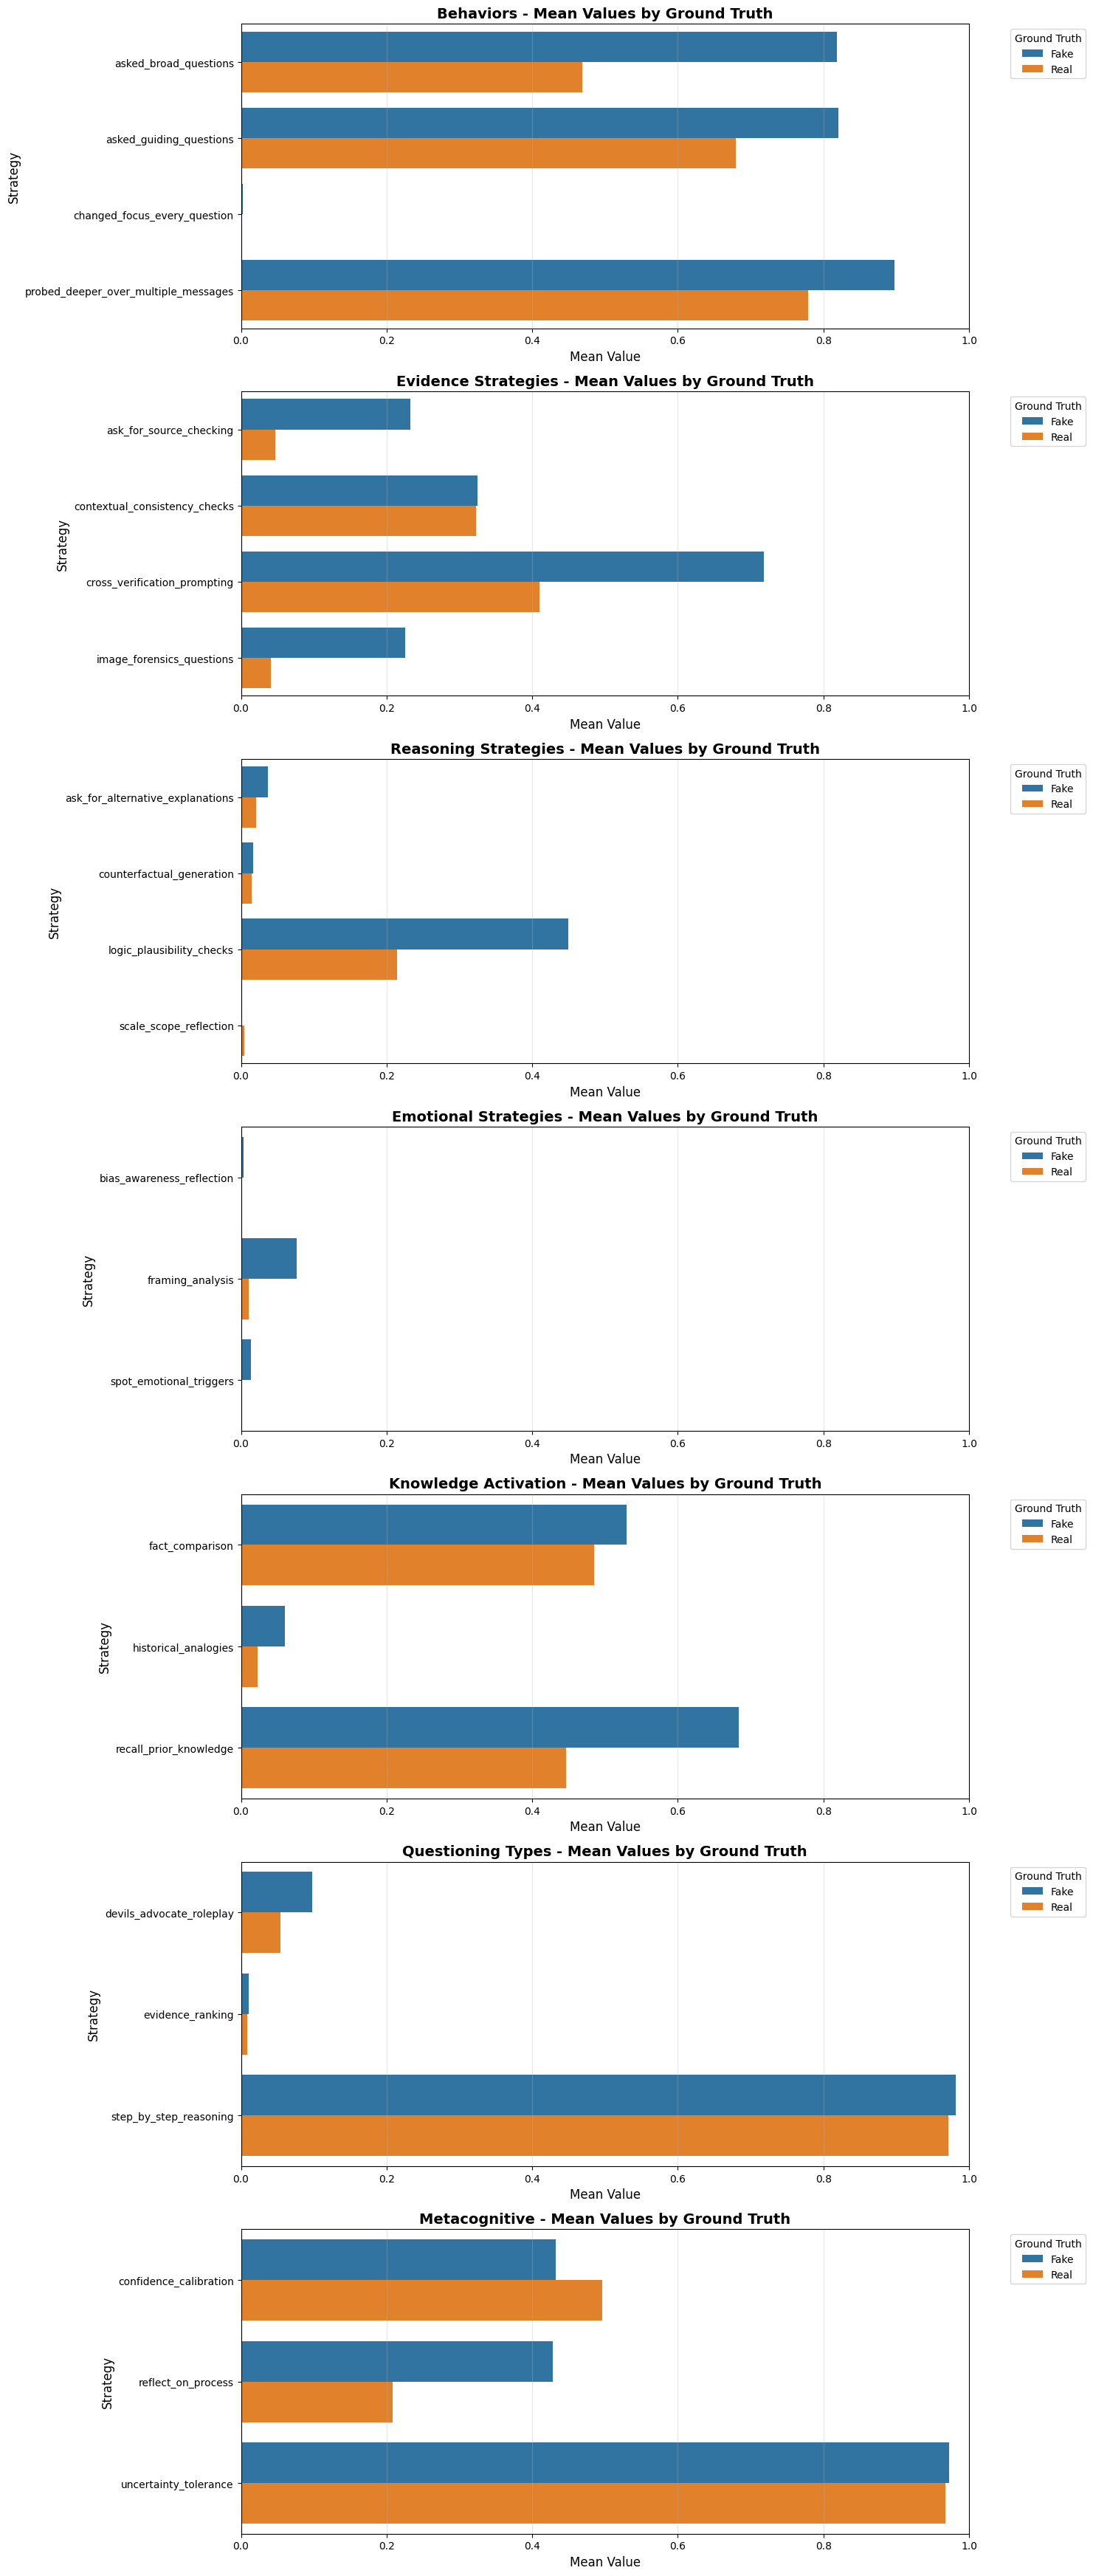

In [41]:
# Fixed visualization with proper ground truth breakdown
# Create subplots for each category group with ground truth comparison
fig, axes = plt.subplots(len(all_categories), 1, figsize=(15, 5 * len(all_categories)))
if len(all_categories) == 1:
    axes = [axes]

for idx, (category_name, category_dict) in enumerate(all_categories.items()):
    # Get the column names that exist in our data
    existing_columns = [col for col in category_dict.keys() if col in data.columns]
    
    if existing_columns:
        # Create subset of data for this category, including ground truth
        category_data = data[existing_columns + ['ground_truth']].copy()
        
        # Melt the data for plotting
        melted_data = category_data.melt(
            id_vars=['ground_truth'], 
            value_vars=existing_columns, 
            var_name='strategy', 
            value_name='value'
        )
        melted_data['value'] = pd.to_numeric(melted_data['value'], errors='coerce')
        melted_data = melted_data.dropna(subset=['value'])
        
        # Calculate mean values grouped by strategy and ground truth
        grouped_data = melted_data.groupby(['strategy', 'ground_truth'])['value'].mean().reset_index()
        
        # Create horizontal bar plot with ground truth as hue
        sns.barplot(
            data=grouped_data, 
            x='value', 
            y='strategy', 
            hue='ground_truth', 
            ax=axes[idx], 
            palette=['#1f77b4', '#ff7f0e'],  # Blue for False, Orange for True
            orient='h'
        )
        
        axes[idx].set_title(f'{category_name} - Mean Values by Ground Truth', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Mean Value', fontsize=12)
        axes[idx].set_ylabel('Strategy', fontsize=12)
        axes[idx].set_xlim(0, 1)
        axes[idx].grid(axis='x', alpha=0.3)
        axes[idx].legend(title='Ground Truth', bbox_to_anchor=(1.05, 1), loc='upper left')
        
    else:
        axes[idx].text(0.5, 0.5, f'No data found for {category_name}', 
                      ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
        axes[idx].set_title(f'{category_name} - No Data Available', fontsize=14)

plt.tight_layout()
plt.show()

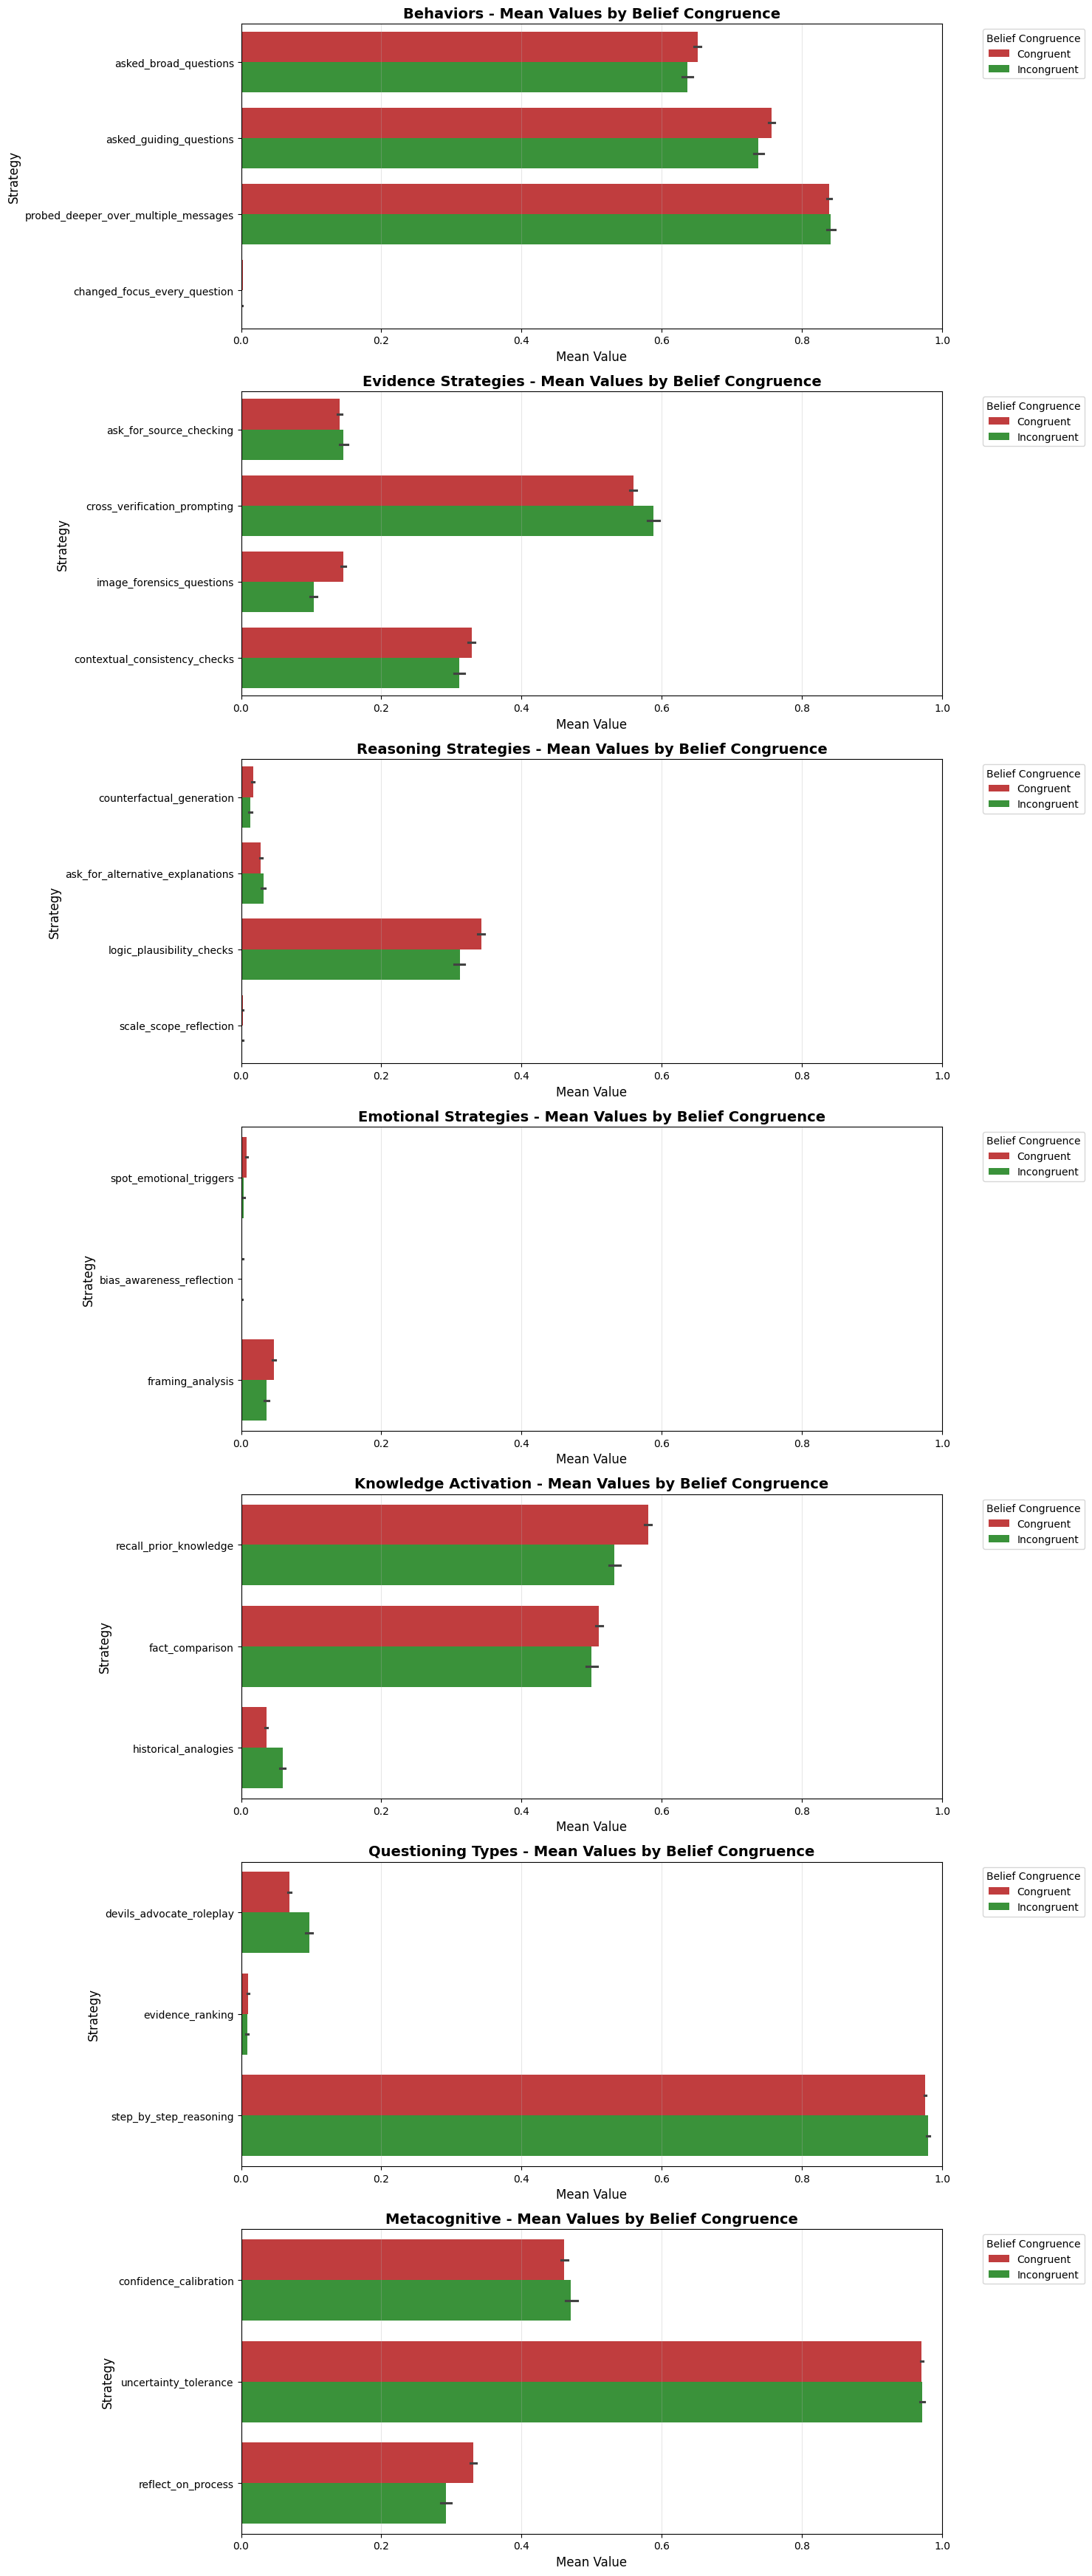

Distribution of belief congruence:
congruent_belief
Congruent      41119
Incongruent    14970
Name: count, dtype: int64

Percentages:
congruent_belief
Congruent      73.310275
Incongruent    26.689725
Name: proportion, dtype: float64


In [48]:
# Visualization with congruent vs incongruent belief breakdown
# Create subplots for each category group with congruent belief comparison
fig, axes = plt.subplots(len(all_categories), 1, figsize=(15, 5 * len(all_categories)))
if len(all_categories) == 1:
    axes = [axes]

for idx, (category_name, category_dict) in enumerate(all_categories.items()):
    # Get the column names that exist in our data
    existing_columns = [col for col in category_dict.keys() if col in data.columns]
    
    if existing_columns:
        # Create subset of data for this category, including congruent_belief
        category_data = data[existing_columns + ['congruent_belief']].copy()
        
        # Melt the data for plotting
        melted_data = category_data.melt(
            id_vars=['congruent_belief'], 
            value_vars=existing_columns, 
            var_name='strategy', 
            value_name='value'
        )
        melted_data['value'] = pd.to_numeric(melted_data['value'], errors='coerce')
        melted_data = melted_data.dropna(subset=['value'])
        
        # Calculate mean values grouped by strategy and congruent_belief
        #grouped_data = melted_data.groupby(['strategy', 'congruent_belief'])['value'].mean().reset_index()
        
        # Create horizontal bar plot with congruent_belief as hue
        sns.barplot(
            data=melted_data, 
            x='value', 
            y='strategy', 
            hue='congruent_belief', 
            ax=axes[idx], 
            palette=['#d62728', '#2ca02c'],  # Red for Incongruent, Green for Congruent
            orient='h'
        )
        
        axes[idx].set_title(f'{category_name} - Mean Values by Belief Congruence', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Mean Value', fontsize=12)
        axes[idx].set_ylabel('Strategy', fontsize=12)
        axes[idx].set_xlim(0, 1)
        axes[idx].grid(axis='x', alpha=0.3)
        axes[idx].legend(title='Belief Congruence', bbox_to_anchor=(1.05, 1), loc='upper left')
        
    else:
        axes[idx].text(0.5, 0.5, f'No data found for {category_name}', 
                      ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
        axes[idx].set_title(f'{category_name} - No Data Available', fontsize=14)

plt.tight_layout()
plt.show()

# Show distribution of congruent vs incongruent beliefs
print("Distribution of belief congruence:")
print(data['congruent_belief'].value_counts())
print(f"\nPercentages:")
print(data['congruent_belief'].value_counts(normalize=True) * 100)

/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


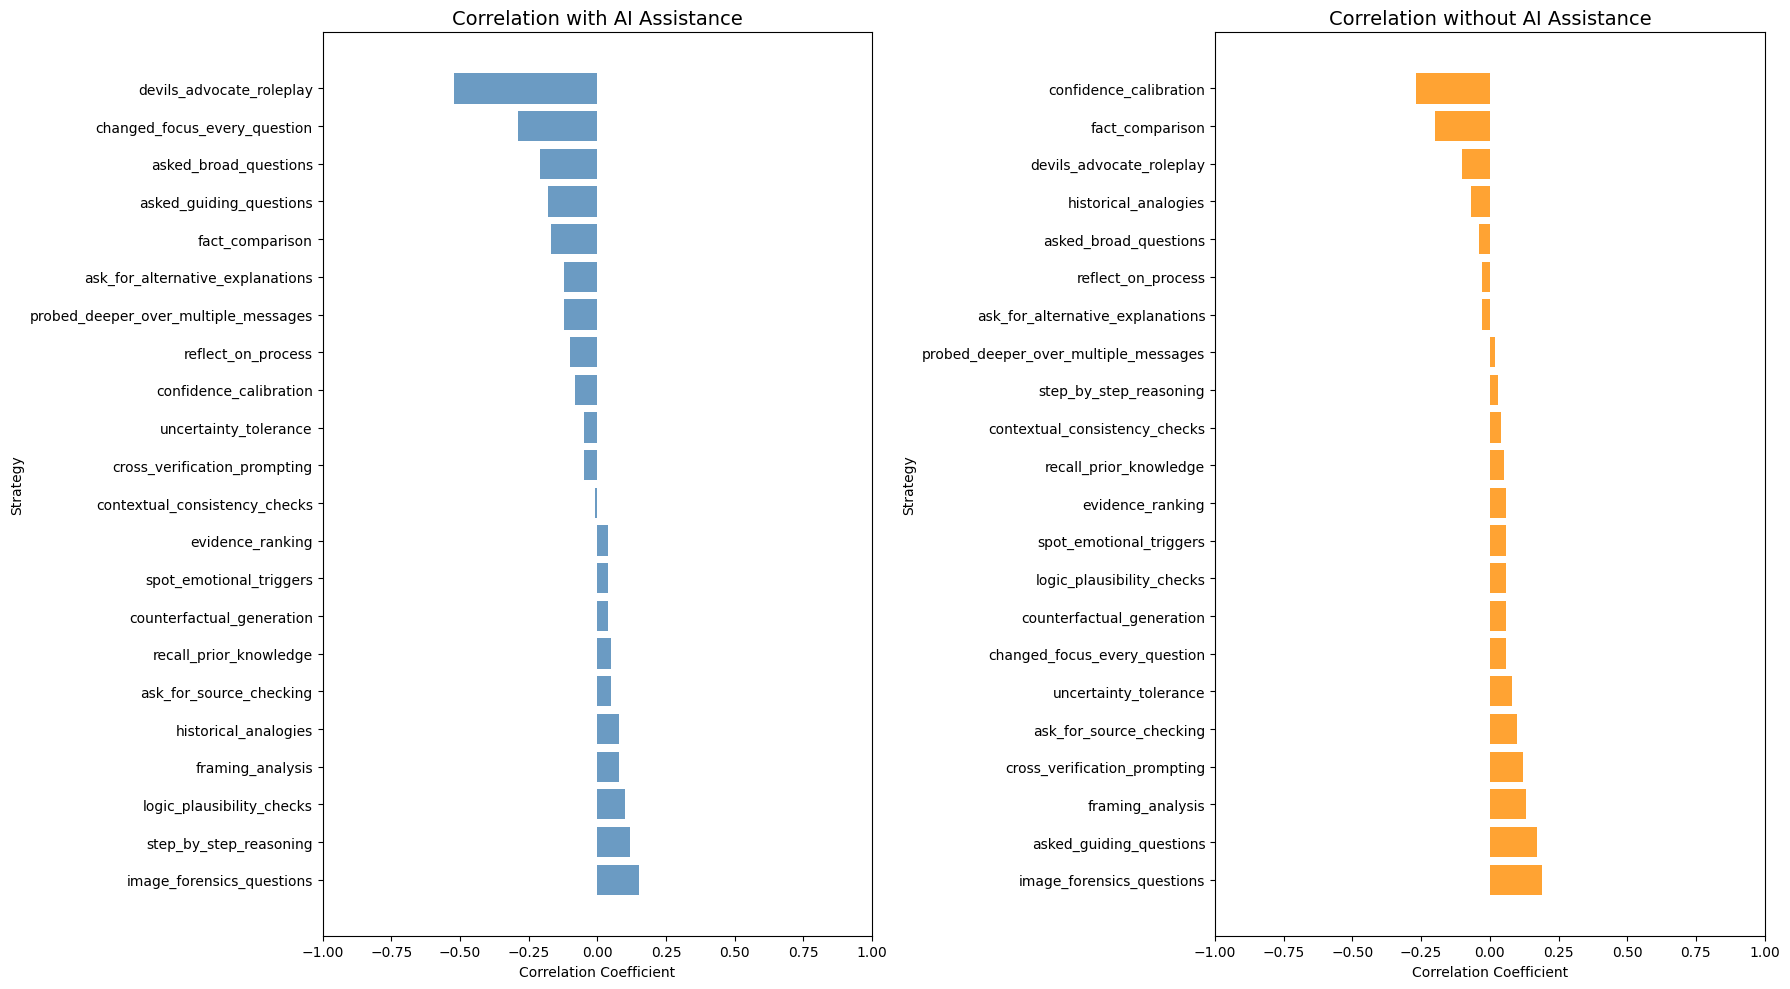

In [169]:
# correlation between accuracy and all strategies
# print the correlation coefficients between accuracy and all strategies
correlations_with = {}
correlations_unassisted = {}
for category_name, category_dict in all_categories.items():
    for strategy in category_dict.keys():
        if strategy in data.columns:

            corr = data[['accuracy_with', strategy]].dropna()
            corr = corr['accuracy_with'].corr(corr[strategy])
            correlations_with[strategy] = round(corr,2)
            corr_unassisted = data['accuracy_unassisted'].corr(data[strategy])
            correlations_unassisted[strategy] = round(corr_unassisted,2)

# sort and print correlations for each with and without assistance
correlations_with = dict(sorted(correlations_with.items(), key=lambda item: item[1], reverse=True))
correlations_unassisted = dict(sorted(correlations_unassisted.items(), key=lambda item: item[1], reverse=True))

# prep fig
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Remove strategies with NaN correlations for plotting
plot_corr_with = {k: v for k, v in correlations_with.items() if not np.isnan(v)}
plot_corr_unassisted = {k: v for k, v in correlations_unassisted.items() if not np.isnan(v)}


# Plot for "with AI assistance"
axes[0].barh(list(plot_corr_with.keys()), list(plot_corr_with.values()), color='steelblue', alpha=0.8)
axes[0].set_title("Correlation with AI Assistance", fontsize=14)
axes[0].set_xlabel("Correlation Coefficient")
axes[0].set_ylabel("Strategy")
axes[0].set_xlim(-1, 1)

# Plot for "without AI assistance"
axes[1].barh(list(plot_corr_unassisted.keys()), list(plot_corr_unassisted.values()), color='darkorange', alpha=0.8)
axes[1].set_title("Correlation without AI Assistance", fontsize=14)
axes[1].set_xlabel("Correlation Coefficient")
axes[1].set_ylabel("Strategy")
axes[1].set_xlim(-1, 1)

plt.tight_layout()
plt.show()

/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages

Correlations with AI Assistance:
image_forensics_questions: 0.23
recall_prior_knowledge: 0.23
framing_analysis: 0.12
historical_analogies: 0.12
logic_plausibility_checks: 0.08
spot_emotional_triggers: 0.06
evidence_ranking: 0.06
ask_for_source_checking: 0.05
contextual_consistency_checks: 0.04
reflect_on_process: 0.01
confidence_calibration: -0.11
probed_deeper_over_multiple_messages: -0.12
asked_guiding_questions: -0.18
cross_verification_prompting: -0.18
asked_broad_questions: -0.2
ask_for_alternative_explanations: -0.21
fact_comparison: -0.28
devils_advocate_roleplay: -0.56

Correlations without AI Assistance:
asked_guiding_questions: 0.29
probed_deeper_over_multiple_messages: 0.19
image_forensics_questions: 0.18
recall_prior_knowledge: 0.17
framing_analysis: 0.16
ask_for_source_checking: 0.13
logic_plausibility_checks: 0.12
spot_emotional_triggers: 0.08
evidence_ranking: 0.08
asked_broad_questions: -0.01
historical_analogies: -0.01
reflect_on_process: -0.02
contextual_consistency_c

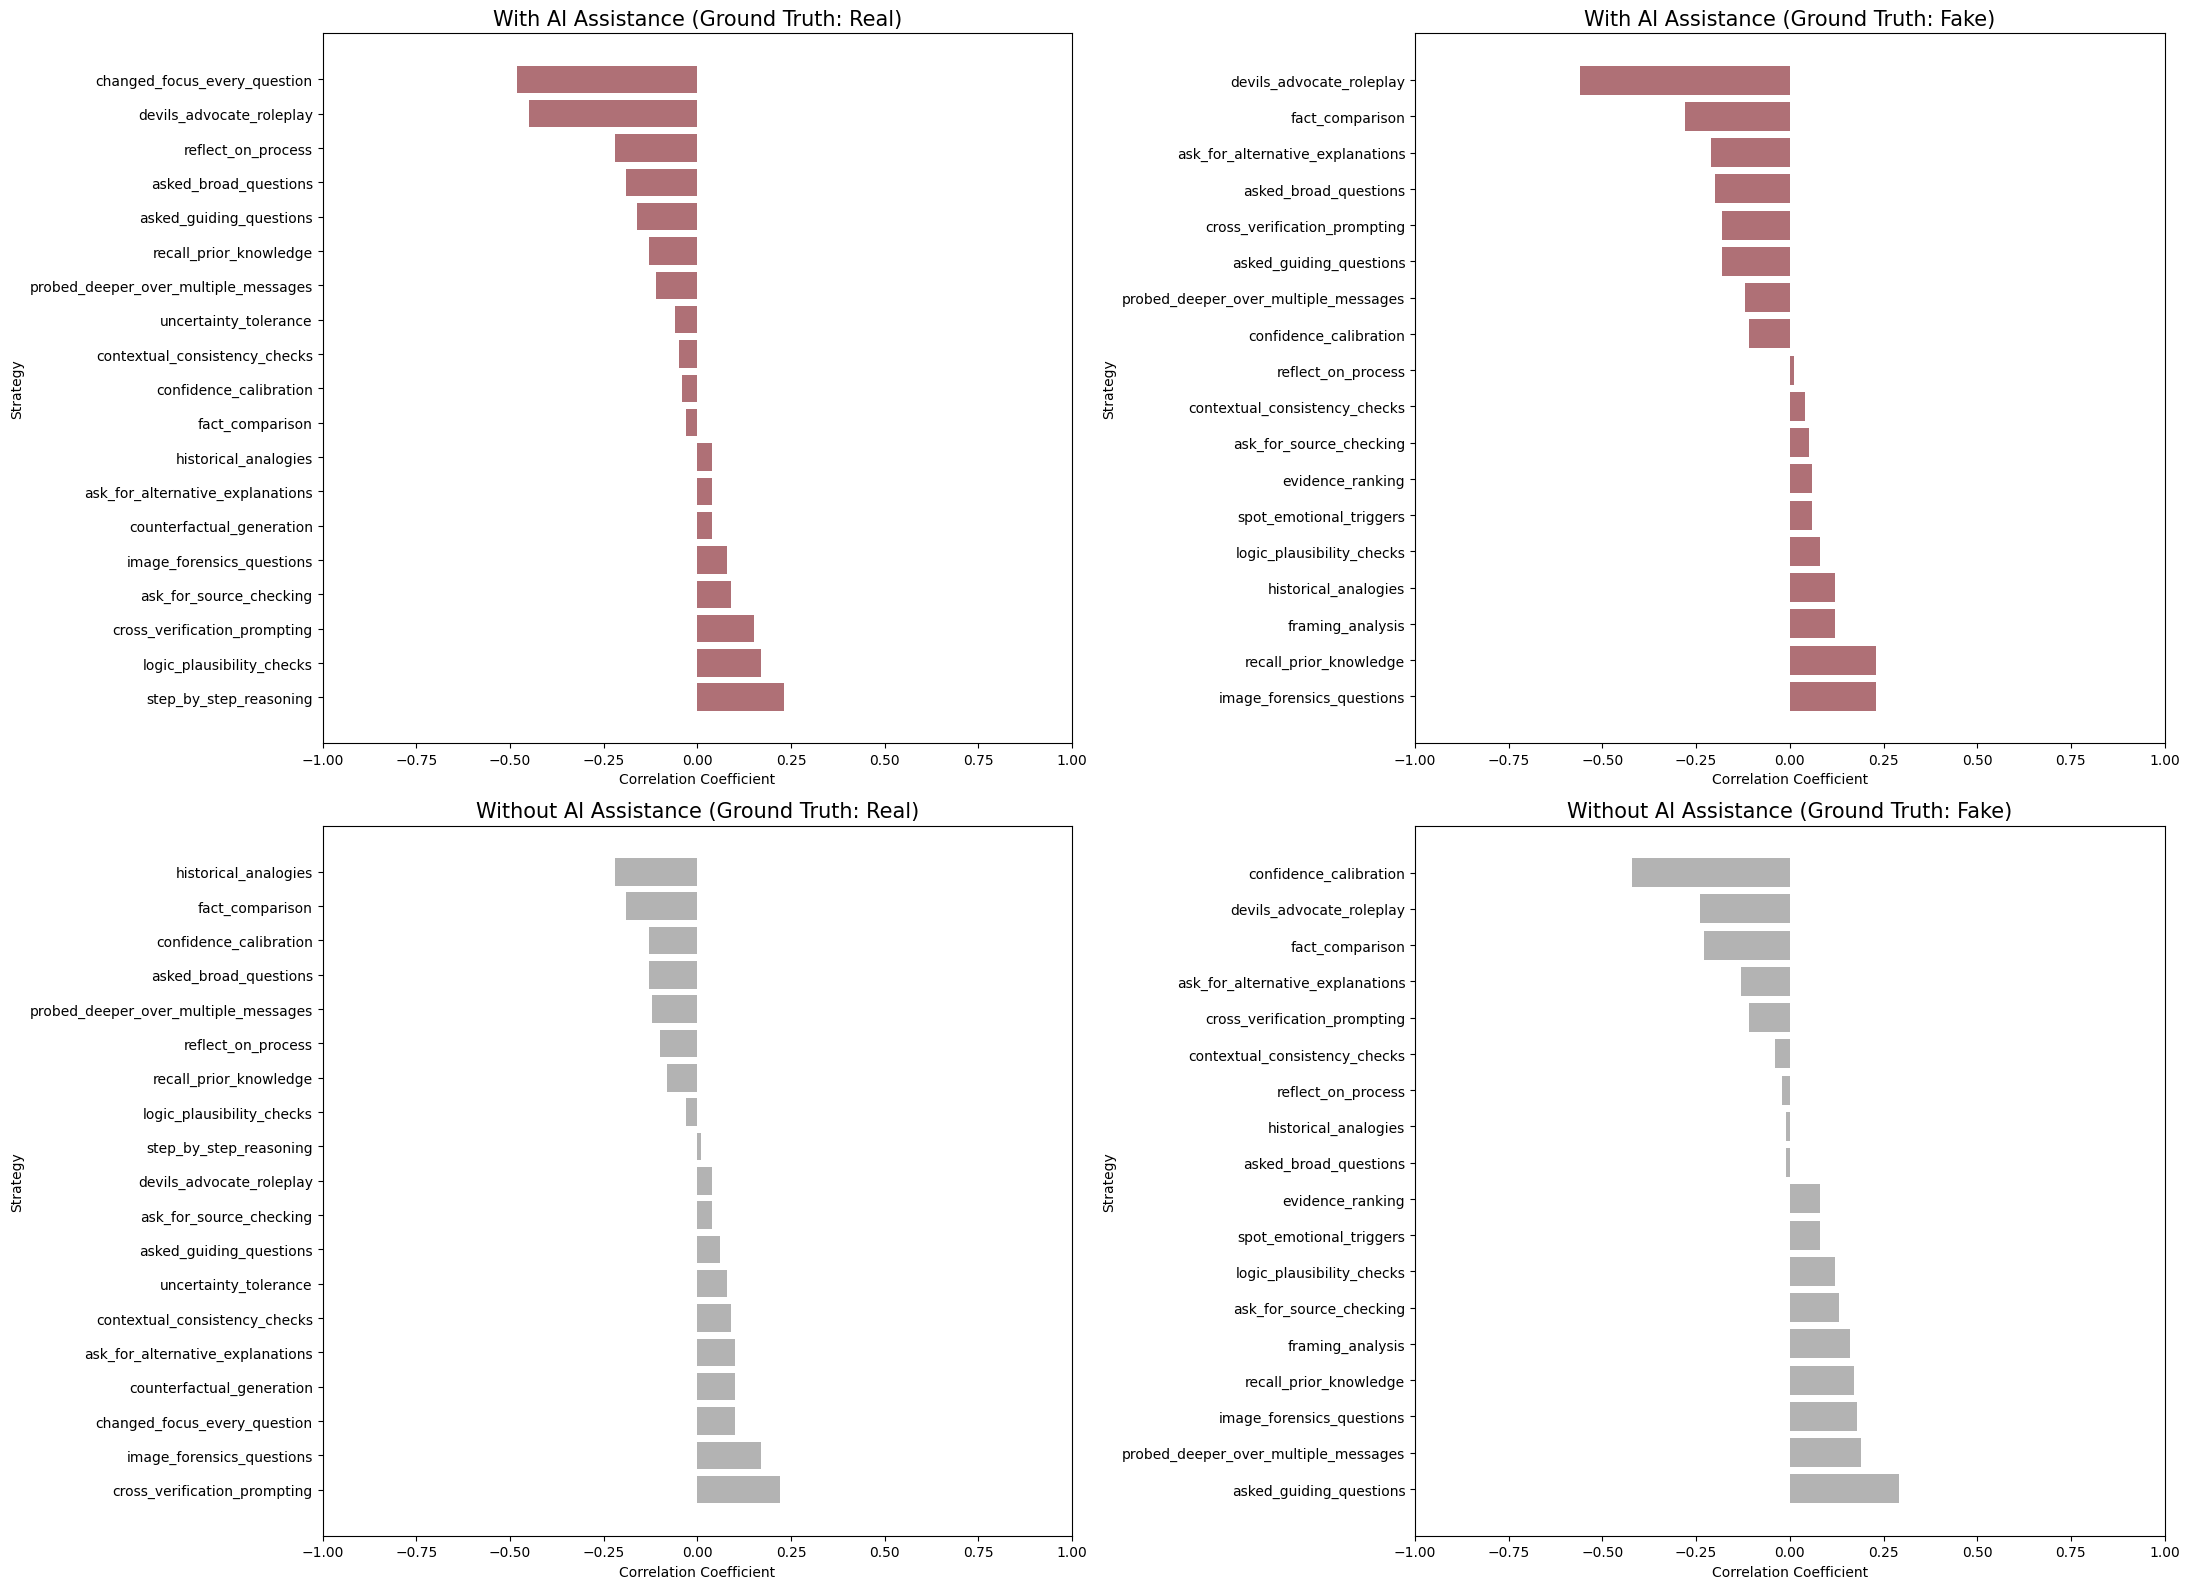

In [178]:
# print the correlation coefficients between accuracy and all strategies
# split by ground truth real vs. fake

# Calculate correlations between accuracy and all strategies, split by ground truth (Real vs. Fake)
correlations_with = {'Real': {}, 'Fake': {}}
correlations_unassisted = {'Real': {}, 'Fake': {}}

for gt in ['Real', 'Fake']:
    subset = data[data['ground_truth'] == gt]
    for category_name, category_dict in all_categories.items():
        for strategy in category_dict.keys():
            if strategy in subset.columns:
                corr_with = subset[['accuracy_with', strategy]].dropna()
                if not corr_with.empty:
                    corr = corr_with['accuracy_with'].corr(pd.to_numeric(corr_with[strategy], errors='coerce'))
                    correlations_with[gt][strategy] = round(corr, 2) if not pd.isna(corr) else np.nan
                else:
                    correlations_with[gt][strategy] = np.nan

                corr_unassist = subset[['accuracy_unassisted', strategy]].dropna()
                if not corr_unassist.empty:
                    corr_un = corr_unassist['accuracy_unassisted'].corr(pd.to_numeric(corr_unassist[strategy], errors='coerce'))
                    correlations_unassisted[gt][strategy] = round(corr_un, 2) if not pd.isna(corr_un) else np.nan
                else:
                    correlations_unassisted[gt][strategy] = np.nan

# Define a safe sorting key function that properly handles NaN values
def safe_sort_key(item):
    """Safe sorting key that handles NaN values properly"""
    value = item[1]
    if pd.isna(value):
        return -np.inf  # Put NaN values at the end (lowest)
    return value

# Sort for plotting (descending) for each ground truth group
# Using the improved sorting approach
fake_with_order = [k for k, v in sorted(correlations_with['Fake'].items(), key=safe_sort_key, reverse=True)]
fake_unassist_order = [k for k, v in sorted(correlations_unassisted['Fake'].items(), key=safe_sort_key, reverse=True)]
real_with_order = [k for k, v in sorted(correlations_with['Real'].items(), key=safe_sort_key, reverse=True)]
real_unassist_order = [k for k, v in sorted(correlations_unassisted['Real'].items(), key=safe_sort_key, reverse=True)]

# Reorder all dicts for plotting
correlations_with['Real'] = {k: correlations_with['Real'][k] for k in real_with_order}
correlations_with['Fake'] = {k: correlations_with['Fake'][k] for k in fake_with_order}
correlations_unassisted['Real'] = {k: correlations_unassisted['Real'][k] for k in real_unassist_order}
correlations_unassisted['Fake'] = {k: correlations_unassisted['Fake'][k] for k in fake_unassist_order}

# Print sorted correlations to verify
print("Correlations with AI Assistance:")
for strategy in fake_with_order:
    corr_val = correlations_with['Fake'][strategy]
    if not pd.isna(corr_val):
        print(f"{strategy}: {corr_val}")

print("\nCorrelations without AI Assistance:")
for strategy in fake_unassist_order:
    corr_val = correlations_unassisted['Fake'][strategy]
    if not pd.isna(corr_val):
        print(f"{strategy}: {corr_val}")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
titles = [
    "With AI Assistance (Ground Truth: Real)",
    "With AI Assistance (Ground Truth: Fake)",
    "Without AI Assistance (Ground Truth: Real)",
    "Without AI Assistance (Ground Truth: Fake)"
]
plot_data = [
    correlations_with['Real'],
    correlations_with['Fake'],
    correlations_unassisted['Real'],
    correlations_unassisted['Fake']
]

without_ai_color = '#A0A0A0'
with_ai_color = '#9B4C54'

for i, ax in enumerate(axes.flat):
    plot_corr = {k: v for k, v in plot_data[i].items() if not pd.isna(v)}
    ax.barh(list(plot_corr.keys()), list(plot_corr.values()), color=with_ai_color if i < 2 else without_ai_color, alpha=0.8)
    ax.set_title(titles[i], fontsize=15)
    ax.set_xlabel("Correlation Coefficient")
    ax.set_ylabel("Strategy")
    ax.set_xlim(-1, 1)
        
plt.tight_layout()
plt.show()

/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages

=== APPLYING RELIABILITY FILTERS ===
RELIABLE Correlations with AI Assistance (Fake News):
  image_forensics_questions: 0.23 (occurs 22.9%, n=11)
  recall_prior_knowledge: 0.23 (occurs 68.8%, n=33)
  logic_plausibility_checks: 0.08 (occurs 37.5%, n=18)
  ask_for_source_checking: 0.05 (occurs 18.8%, n=9)
  contextual_consistency_checks: 0.04 (occurs 33.3%, n=16)
  reflect_on_process: 0.01 (occurs 43.8%, n=21)
  confidence_calibration: -0.11 (occurs 43.8%, n=21)
  probed_deeper_over_multiple_messages: -0.12 (occurs 91.7%, n=44)
  asked_guiding_questions: -0.18 (occurs 83.3%, n=40)
  cross_verification_prompting: -0.18 (occurs 83.3%, n=40)
  asked_broad_questions: -0.2 (occurs 81.2%, n=39)
  fact_comparison: -0.28 (occurs 52.1%, n=25)
  devils_advocate_roleplay: -0.56 (occurs 12.5%, n=6)

RELIABLE Correlations without AI Assistance (Fake News):
  asked_guiding_questions: 0.29 (occurs 83.3%, n=40)
  probed_deeper_over_multiple_messages: 0.19 (occurs 91.7%, n=44)
  image_forensics_questions

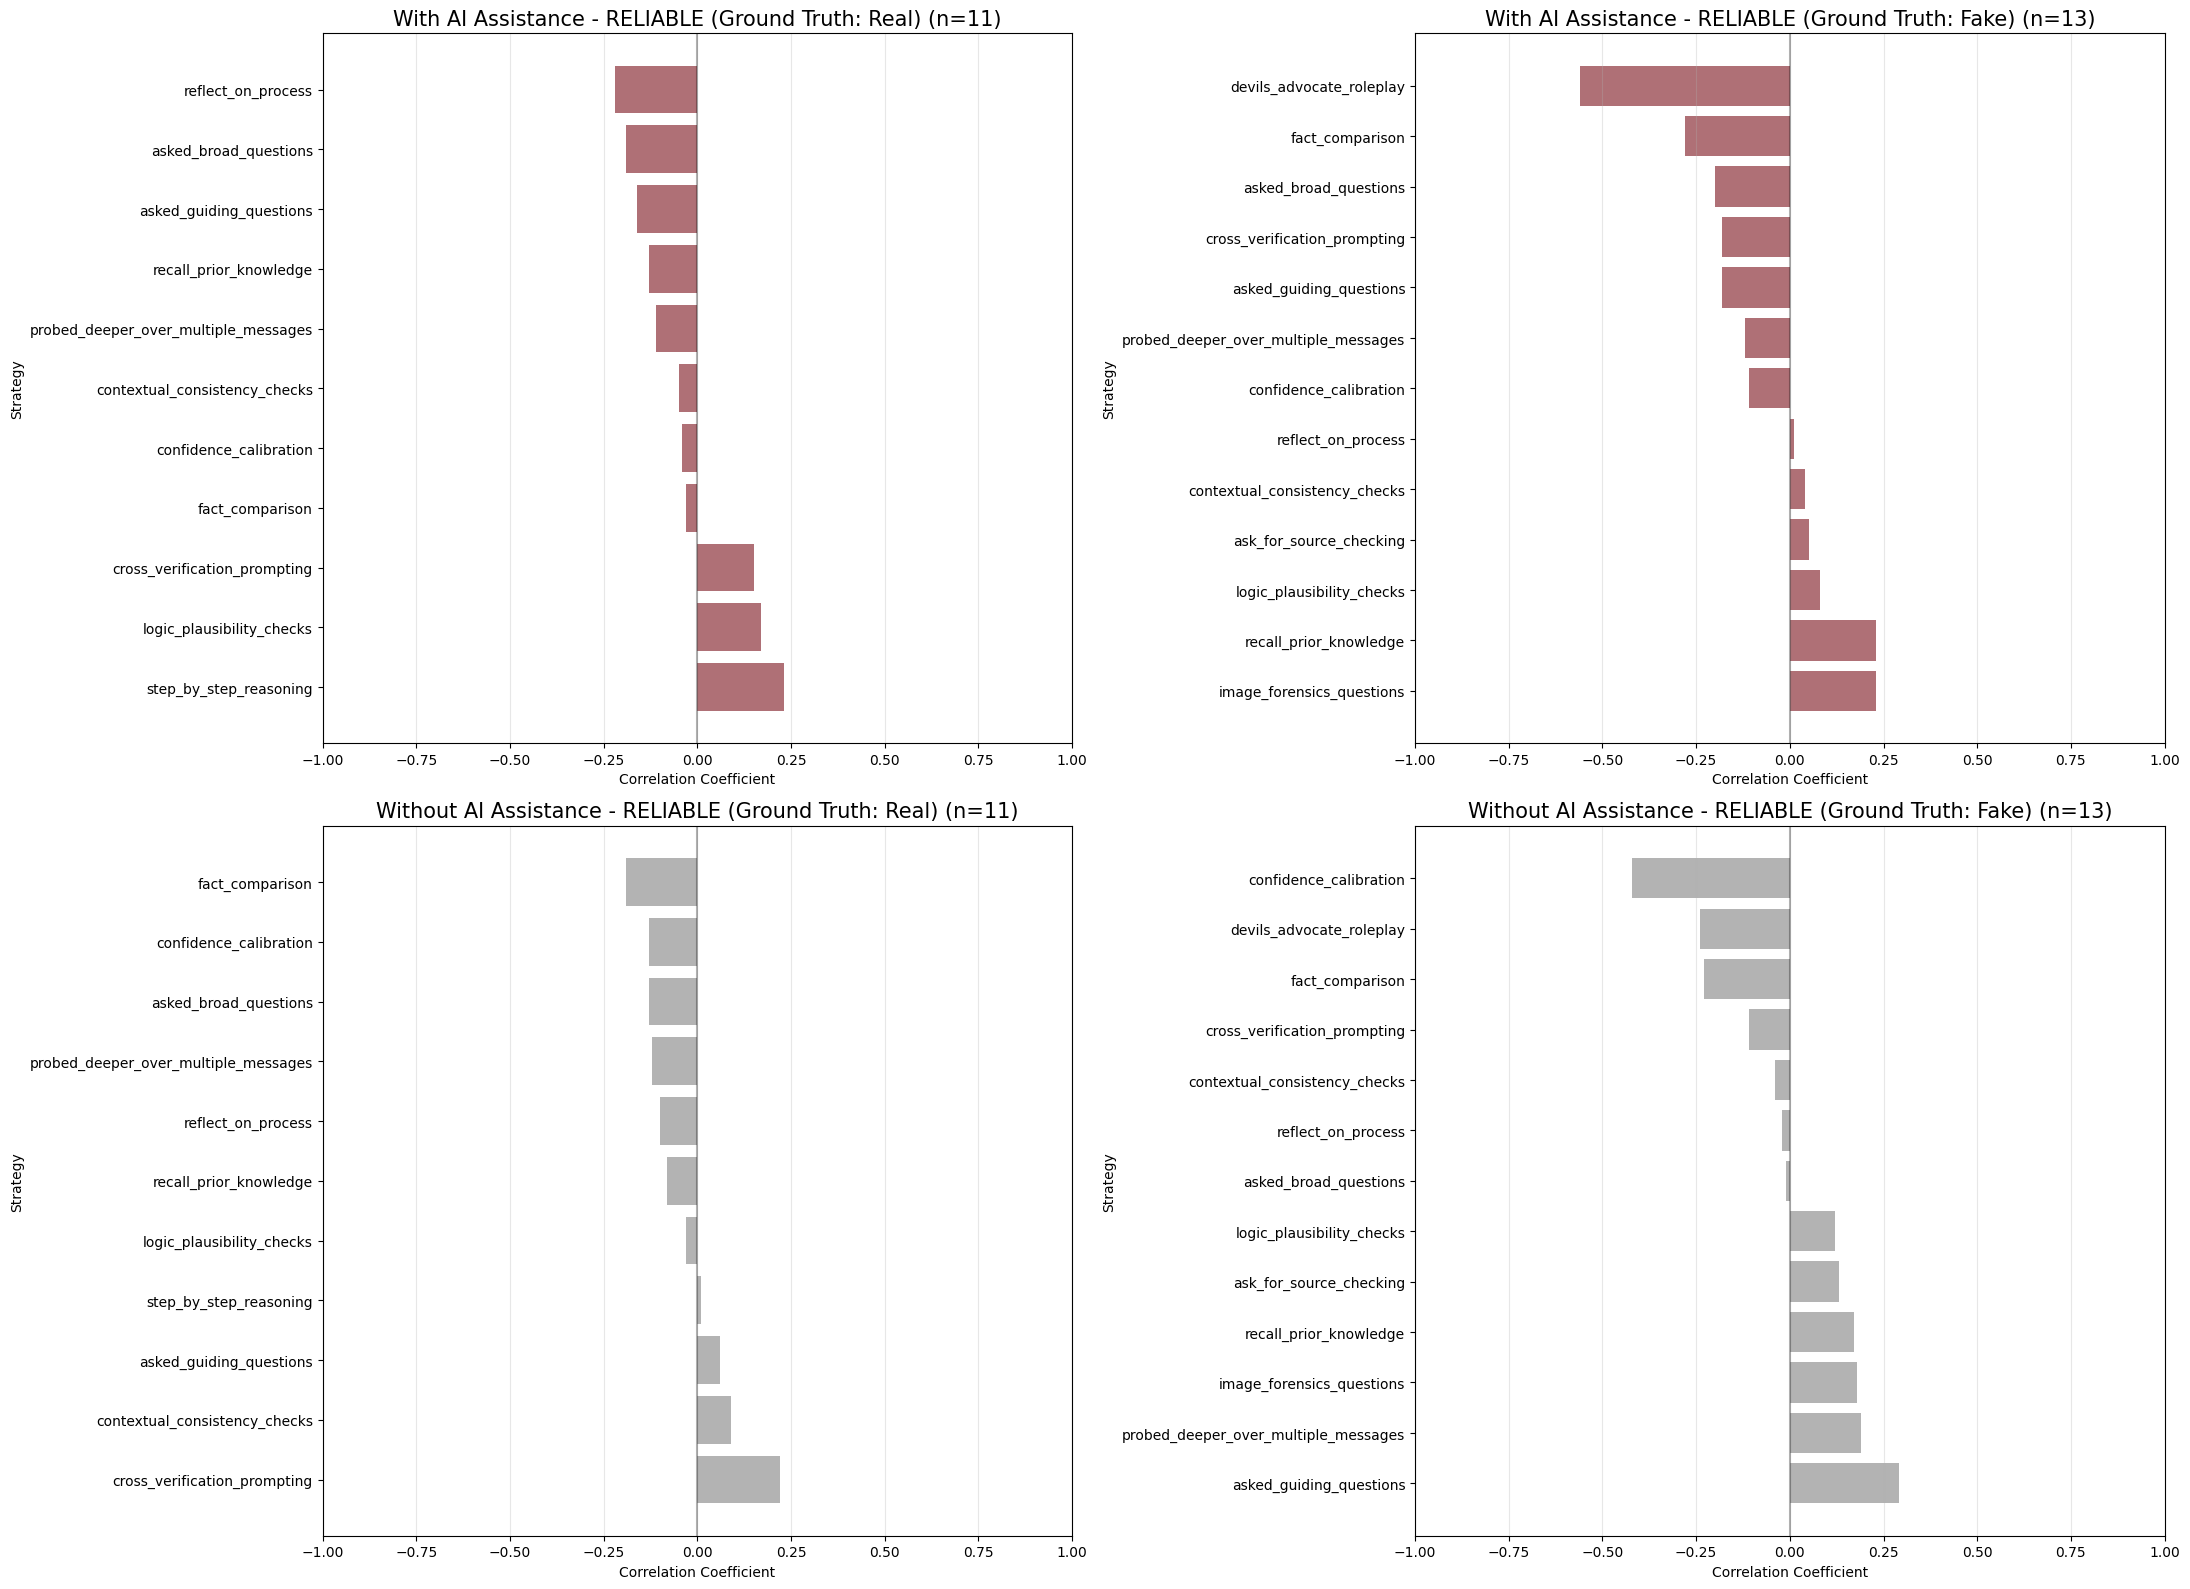

In [180]:
## Filter for occurrence rate between 5% and 95%, At least 10 positive cases, Sufficient variance (> 0.05)
# Calculate correlations between accuracy and all strategies, split by ground truth (Real vs. Fake)
correlations_with = {'Real': {}, 'Fake': {}}
correlations_unassisted = {'Real': {}, 'Fake': {}}

for gt in ['Real', 'Fake']:
    subset = data[data['ground_truth'] == gt]
    for category_name, category_dict in all_categories.items():
        for strategy in category_dict.keys():
            if strategy in subset.columns:
                corr_with = subset[['accuracy_with', strategy]].dropna()
                if not corr_with.empty:
                    corr = corr_with['accuracy_with'].corr(pd.to_numeric(corr_with[strategy], errors='coerce'))
                    correlations_with[gt][strategy] = round(corr, 2) if not pd.isna(corr) else np.nan
                else:
                    correlations_with[gt][strategy] = np.nan

                corr_unassist = subset[['accuracy_unassisted', strategy]].dropna()
                if not corr_unassist.empty:
                    corr_un = corr_unassist['accuracy_unassisted'].corr(pd.to_numeric(corr_unassist[strategy], errors='coerce'))
                    correlations_unassisted[gt][strategy] = round(corr_un, 2) if not pd.isna(corr_un) else np.nan
                else:
                    correlations_unassisted[gt][strategy] = np.nan

# Define a safe sorting key function that properly handles NaN values
def safe_sort_key(item):
    """Safe sorting key that handles NaN values properly"""
    value = item[1]
    if pd.isna(value):
        return -np.inf  # Put NaN values at the end (lowest)
    return value

# Sort for plotting (descending) for each ground truth group
# Using the improved sorting approach
fake_with_order = [k for k, v in sorted(correlations_with['Fake'].items(), key=safe_sort_key, reverse=True)]
fake_unassist_order = [k for k, v in sorted(correlations_unassisted['Fake'].items(), key=safe_sort_key, reverse=True)]
real_with_order = [k for k, v in sorted(correlations_with['Real'].items(), key=safe_sort_key, reverse=True)]
real_unassist_order = [k for k, v in sorted(correlations_unassisted['Real'].items(), key=safe_sort_key, reverse=True)]

# Reorder all dicts for plotting
correlations_with['Real'] = {k: correlations_with['Real'][k] for k in real_with_order}
correlations_with['Fake'] = {k: correlations_with['Fake'][k] for k in fake_with_order}
correlations_unassisted['Real'] = {k: correlations_unassisted['Real'][k] for k in real_unassist_order}
correlations_unassisted['Fake'] = {k: correlations_unassisted['Fake'][k] for k in fake_unassist_order}

# Apply reliability filters to identify trustworthy correlations
print("=== APPLYING RELIABILITY FILTERS ===")

# Calculate occurrence rates and variance for filtering
occurrence_rates = {}
variance_analysis = {}

for gt in ['Real', 'Fake']:
    subset = data[data['ground_truth'] == gt]
    occurrence_rates[gt] = {}
    variance_analysis[gt] = {}
    
    for category_name, category_dict in all_categories.items():
        for strategy in category_dict.keys():
            if strategy in subset.columns:
                strategy_col = pd.to_numeric(subset[strategy], errors='coerce')
                occurrence_rate = strategy_col.mean()
                n_positive = (strategy_col == 1).sum()
                variance = strategy_col.var()
                
                occurrence_rates[gt][strategy] = occurrence_rate
                variance_analysis[gt][strategy] = {
                    'variance': variance,
                    'n_positive': n_positive
                }

# Filter correlations based on reliability criteria
def filter_reliable_correlations(correlations_dict, gt):
    """Filter correlations to only include reliable strategies"""
    reliable_corr = {}
    for strategy, corr_val in correlations_dict.items():
        if strategy in occurrence_rates[gt]:
            occ_rate = occurrence_rates[gt][strategy]
            n_pos = variance_analysis[gt][strategy]['n_positive']
            variance = variance_analysis[gt][strategy]['variance']
            
            # Apply reliability criteria
            if (0.05 <= occ_rate <= 0.95 and 
                n_pos >= 5 and 
                variance > 0.05 and 
                not pd.isna(corr_val)):
                reliable_corr[strategy] = corr_val
    return reliable_corr

# Apply filters to all correlation dictionaries
filtered_correlations_with = {
    'Real': filter_reliable_correlations(correlations_with['Real'], 'Real'),
    'Fake': filter_reliable_correlations(correlations_with['Fake'], 'Fake')
}

filtered_correlations_unassisted = {
    'Real': filter_reliable_correlations(correlations_unassisted['Real'], 'Real'),
    'Fake': filter_reliable_correlations(correlations_unassisted['Fake'], 'Fake')
}

# Sort filtered correlations
for gt in ['Real', 'Fake']:
    filtered_correlations_with[gt] = dict(sorted(filtered_correlations_with[gt].items(), key=lambda x: x[1], reverse=True))
    filtered_correlations_unassisted[gt] = dict(sorted(filtered_correlations_unassisted[gt].items(), key=lambda x: x[1], reverse=True))

# Print filtered correlations
print("RELIABLE Correlations with AI Assistance (Fake News):")
for strategy, corr_val in filtered_correlations_with['Fake'].items():
    occ_rate = occurrence_rates['Fake'][strategy]
    n_pos = variance_analysis['Fake'][strategy]['n_positive']
    print(f"  {strategy}: {corr_val} (occurs {occ_rate:.1%}, n={n_pos})")

print(f"\nRELIABLE Correlations without AI Assistance (Fake News):")
for strategy, corr_val in filtered_correlations_unassisted['Fake'].items():
    occ_rate = occurrence_rates['Fake'][strategy]
    n_pos = variance_analysis['Fake'][strategy]['n_positive']
    print(f"  {strategy}: {corr_val} (occurs {occ_rate:.1%}, n={n_pos})")

print(f"\nFiltered out {len(correlations_with['Fake']) - len(filtered_correlations_with['Fake'])} unreliable strategies for Fake news")
print(f"Kept {len(filtered_correlations_with['Fake'])} reliable strategies for analysis")

# Plot FILTERED correlations
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
titles = [
    "With AI Assistance - RELIABLE (Ground Truth: Real)",
    "With AI Assistance - RELIABLE (Ground Truth: Fake)",
    "Without AI Assistance - RELIABLE (Ground Truth: Real)",
    "Without AI Assistance - RELIABLE (Ground Truth: Fake)"
]
plot_data = [
    filtered_correlations_with['Real'],
    filtered_correlations_with['Fake'],
    filtered_correlations_unassisted['Real'],
    filtered_correlations_unassisted['Fake']
]

without_ai_color = '#A0A0A0'
with_ai_color = '#9B4C54'

for i, ax in enumerate(axes.flat):
    plot_corr = plot_data[i]
    if plot_corr:  # Only plot if there are reliable correlations
        ax.barh(list(plot_corr.keys()), list(plot_corr.values()), 
                color=with_ai_color if i < 2 else without_ai_color, alpha=0.8)
        ax.set_title(f"{titles[i]} (n={len(plot_corr)})", fontsize=15)
        ax.set_xlabel("Correlation Coefficient")
        ax.set_ylabel("Strategy")
        ax.set_xlim(-1, 1)
        ax.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        
        # Add grid for better readability
        ax.grid(axis='x', alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No reliable correlations\nmeet filtering criteria', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(titles[i], fontsize=15)

plt.tight_layout()
plt.show()

=== STRATEGY TRADE-OFF ANALYSIS ===
Comparing immediate performance (with AI) vs learning benefits (delta improvement)

Strategy Categories by News Type:

Real News:
  Learning Enhancer: 5 strategies
  Balanced: 3 strategies
  Performance Booster: 3 strategies

Fake News:
  Performance Booster: 5 strategies
  Balanced: 4 strategies
  Learning Enhancer: 4 strategies


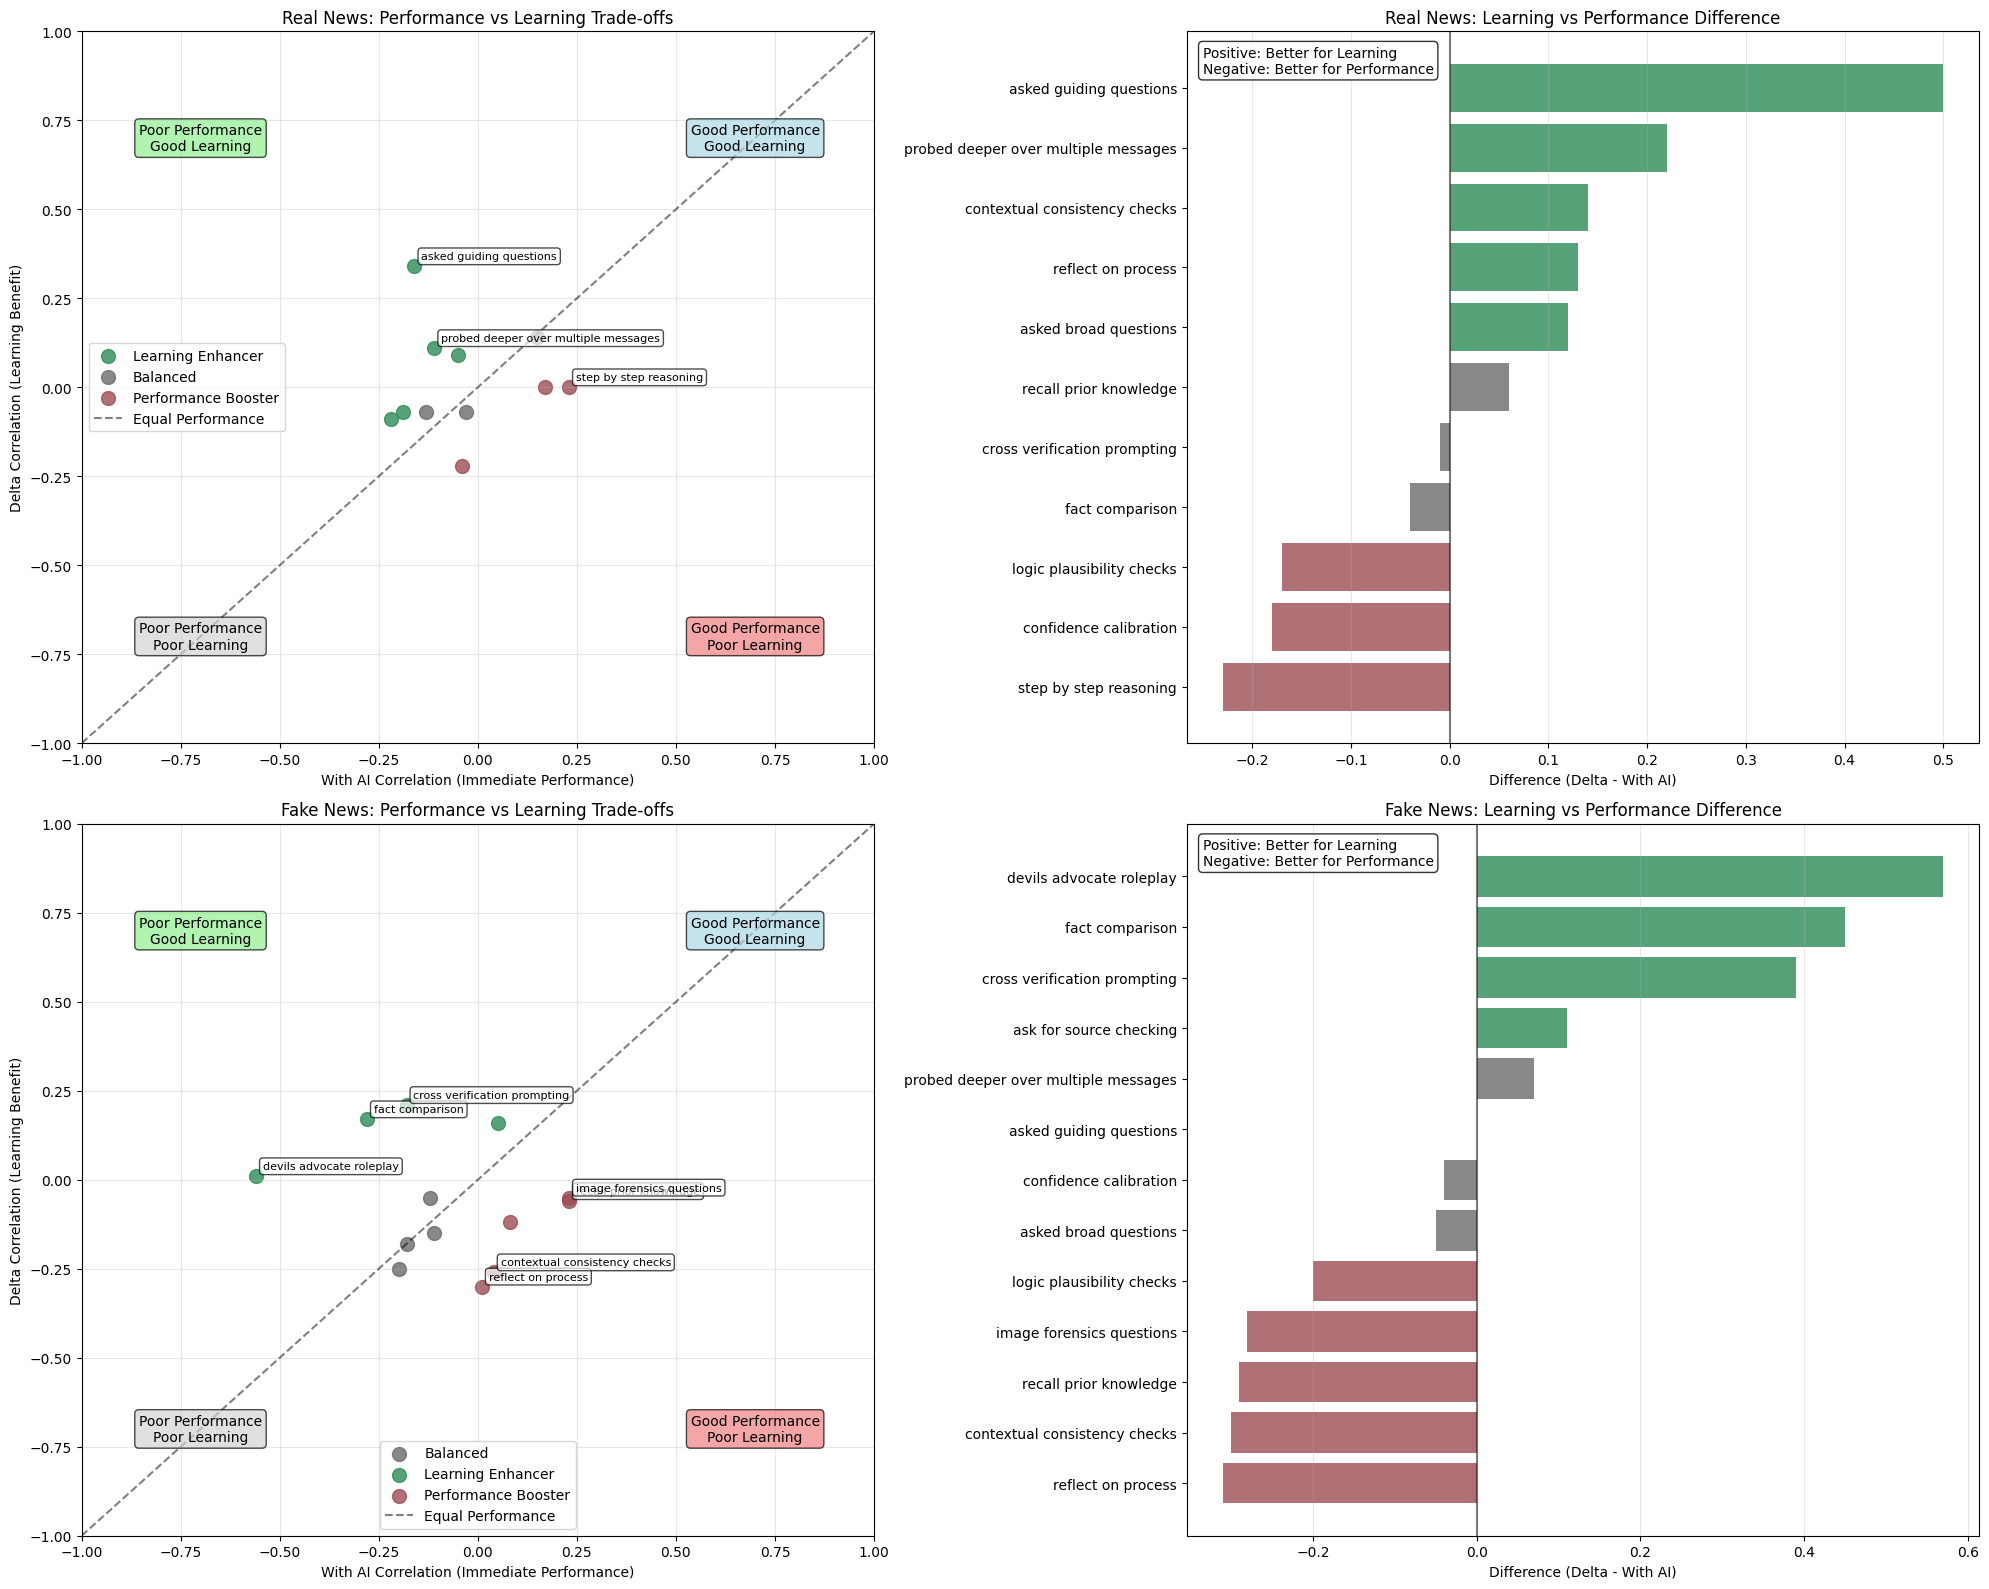


=== DETAILED TRADE-OFF ANALYSIS ===

--- Real News Trade-offs ---

🎓 LEARNING ENHANCERS (Good for skill development, may hurt immediate performance):
  asked_guiding_questions: With AI=-0.16, Delta=0.34 (diff=+0.50)
  probed_deeper_over_multiple_messages: With AI=-0.11, Delta=0.11 (diff=+0.22)
  contextual_consistency_checks: With AI=-0.05, Delta=0.09 (diff=+0.14)
  reflect_on_process: With AI=-0.22, Delta=-0.09 (diff=+0.13)
  asked_broad_questions: With AI=-0.19, Delta=-0.07 (diff=+0.12)

⚡ PERFORMANCE BOOSTERS (Good for immediate results, may limit learning):
  step_by_step_reasoning: With AI=0.23, Delta=0.00 (diff=-0.23)
  confidence_calibration: With AI=-0.04, Delta=-0.22 (diff=-0.18)
  logic_plausibility_checks: With AI=0.17, Delta=0.00 (diff=-0.17)

⚖️  BALANCED STRATEGIES (Good for both immediate performance and learning):
  cross_verification_prompting: With AI=0.15, Delta=0.14 (diff=-0.01)
  fact_comparison: With AI=-0.03, Delta=-0.07 (diff=-0.04)
  recall_prior_knowledge: Wi

In [ ]:
# Strategy Trade-off Analysis: Performance with AI vs Performance after AI
# Compare "with AI" correlations vs "unassisted (after)" correlations to identify trade-offs

print("=== STRATEGY TRADE-OFF ANALYSIS ===")
print("Comparing performance WITH AI vs performance AFTER AI (unassisted)\n")

# Create comparison dataframes for analysis
comparison_data = []

for gt in ['Real', 'Fake']:
    # Get overlapping strategies (those in both filtered sets)
    with_ai_strategies = set(filtered_correlations_with[gt].keys())
    unassisted_strategies = set(filtered_correlations_unassisted[gt].keys())
    
    # Only analyze strategies that appear in both analyses (for fair comparison)
    common_strategies = with_ai_strategies.intersection(unassisted_strategies)
    
    for strategy in common_strategies:
        with_ai_corr = filtered_correlations_with[gt][strategy]
        unassisted_corr = filtered_correlations_unassisted[gt][strategy]
        
        comparison_data.append({
            'strategy': strategy,
            'ground_truth': gt,
            'with_ai_correlation': with_ai_corr,
            'unassisted_correlation': unassisted_corr,
            'difference': unassisted_corr - with_ai_corr,  # Positive = better after AI than during AI
            'category': 'Learning Transfer' if unassisted_corr > with_ai_corr + 0.1 else 
                       'AI Dependent' if with_ai_corr > unassisted_corr + 0.1 else 
                       'Consistent'
        })

comparison_df = pd.DataFrame(comparison_data)

# Print summary statistics
print("Strategy Categories by News Type:")
for gt in ['Real', 'Fake']:
    subset = comparison_df[comparison_df['ground_truth'] == gt]
    print(f"\n{gt} News:")
    category_counts = subset['category'].value_counts()
    for category, count in category_counts.items():
        print(f"  {category}: {count} strategies")

# Create the trade-off visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

for gt_idx, gt in enumerate(['Real', 'Fake']):
    subset = comparison_df[comparison_df['ground_truth'] == gt]
    
    # Scatter plot: With AI vs Delta correlations
    ax1 = axes[gt_idx, 0]
    
    # Color code by category
    colors = {'Learning Enhancer': '#2E8B57', 'Performance Booster': '#9B4C54', 'Balanced': '#6B6B6B'}
    
    for category in subset['category'].unique():
        cat_data = subset[subset['category'] == category]
        ax1.scatter(cat_data['with_ai_correlation'], cat_data['delta_correlation'], 
                   c=colors[category], label=category, alpha=0.8, s=100)
    
    # Add diagonal line (where with_ai = delta)
    ax1.plot([-1, 1], [-1, 1], 'k--', alpha=0.5, label='Equal Performance')
    
    # Add quadrant labels
    ax1.text(0.7, -0.7, 'Good Performance\nPoor Learning', ha='center', va='center', 
             bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
    ax1.text(-0.7, 0.7, 'Poor Performance\nGood Learning', ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
    ax1.text(0.7, 0.7, 'Good Performance\nGood Learning', ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    ax1.text(-0.7, -0.7, 'Poor Performance\nPoor Learning', ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7))
    
    ax1.set_xlabel('With AI Correlation (Immediate Performance)')
    ax1.set_ylabel('Delta Correlation (Learning Benefit)')
    ax1.set_title(f'{gt} News: Performance vs Learning Trade-offs')
    ax1.set_xlim(-1, 1)
    ax1.set_ylim(-1, 1)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Add strategy labels for extreme cases
    for _, row in subset.iterrows():
        if abs(row['difference']) > 0.2:  # Only label strategies with significant differences
            ax1.annotate(row['strategy'].replace('_', ' '), 
                        (row['with_ai_correlation'], row['delta_correlation']),
                        xytext=(5, 5), textcoords='offset points', fontsize=8,
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    
    # Bar plot: Difference (Delta - With AI)
    ax2 = axes[gt_idx, 1]
    
    # Sort by difference
    subset_sorted = subset.sort_values('difference', ascending=True)
    colors_list = [colors[cat] for cat in subset_sorted['category']]
    
    bars = ax2.barh(range(len(subset_sorted)), subset_sorted['difference'], 
                    color=colors_list, alpha=0.8)
    
    ax2.set_yticks(range(len(subset_sorted)))
    ax2.set_yticklabels([s.replace('_', ' ') for s in subset_sorted['strategy']], fontsize=10)
    ax2.set_xlabel('Difference (Delta - With AI)')
    ax2.set_title(f'{gt} News: Learning vs Performance Difference')
    ax2.axvline(x=0, color='black', linestyle='-', alpha=0.5)
    ax2.grid(axis='x', alpha=0.3)
    
    # Add interpretation text
    ax2.text(0.02, 0.98, 'Positive: Better for Learning\nNegative: Better for Performance', 
             transform=ax2.transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Detailed analysis of trade-offs
print("\n=== DETAILED TRADE-OFF ANALYSIS ===")

for gt in ['Real', 'Fake']:
    subset = comparison_df[comparison_df['ground_truth'] == gt]
    print(f"\n--- {gt} News Trade-offs ---")
    
    # Learning enhancers (good for delta, poor for with_ai)
    learning_enhancers = subset[subset['category'] == 'Learning Enhancer'].sort_values('difference', ascending=False)
    if not learning_enhancers.empty:
        print("\n🎓 LEARNING ENHANCERS (Good for skill development, may hurt immediate performance):")
        for _, row in learning_enhancers.iterrows():
            print(f"  {row['strategy']}: With AI={row['with_ai_correlation']:.2f}, Delta={row['delta_correlation']:.2f} (diff={row['difference']:+.2f})")
    
    # Performance boosters (good for with_ai, poor for delta)
    performance_boosters = subset[subset['category'] == 'Performance Booster'].sort_values('difference', ascending=True)
    if not performance_boosters.empty:
        print("\n⚡ PERFORMANCE BOOSTERS (Good for immediate results, may limit learning):")
        for _, row in performance_boosters.iterrows():
            print(f"  {row['strategy']}: With AI={row['with_ai_correlation']:.2f}, Delta={row['delta_correlation']:.2f} (diff={row['difference']:+.2f})")
    
    # Balanced strategies
    balanced = subset[subset['category'] == 'Balanced'].sort_values('with_ai_correlation', ascending=False)
    if not balanced.empty:
        print("\n⚖️  BALANCED STRATEGIES (Good for both immediate performance and learning):")
        for _, row in balanced.iterrows():
            print(f"  {row['strategy']}: With AI={row['with_ai_correlation']:.2f}, Delta={row['delta_correlation']:.2f} (diff={row['difference']:+.2f})")

# Summary insights
print("\n=== KEY INSIGHTS ===")
print("1. LEARNING ENHANCERS: Strategies that promote skill development but may reduce immediate AI-assisted performance")
print("2. PERFORMANCE BOOSTERS: Strategies that maximize immediate results but may limit long-term learning")
print("3. BALANCED STRATEGIES: The 'sweet spot' strategies that benefit both immediate performance and learning")

# Calculate overall patterns
all_data = comparison_df.groupby('category').agg({
    'with_ai_correlation': 'mean',
    'delta_correlation': 'mean',
    'difference': 'mean'
}).round(2)

print(f"\nOverall Patterns (averaged across Real and Fake news):")
for category, row in all_data.iterrows():
    print(f"  {category}: Avg With AI={row['with_ai_correlation']}, Avg Delta={row['delta_correlation']}, Avg Difference={row['difference']:+.2f}")

print(f"\nDesign Recommendation:")
print(f"• For IMMEDIATE accuracy: Focus on Performance Boosters")
print(f"• For LONG-TERM learning: Focus on Learning Enhancers") 
print(f"• For OPTIMAL balance: Focus on Balanced Strategies")